In [1]:
#SaaS 客戶流失分析專案 - Part 1: 資料探索與清理



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


# 設定視覺化風格
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [2]:
# 步驟 1：載入所有資料表
# 定義檔案路徑
data_path = '/content/'

# 載入各個 CSV 檔案
# pd.read_csv() 是 pandas 最常用的函數，用來讀取 CSV 檔案
accounts = pd.read_csv(data_path + 'ravenstack_accounts.csv')
subscriptions = pd.read_csv(data_path + 'ravenstack_subscriptions.csv')
churn_events = pd.read_csv(data_path + 'ravenstack_churn_events.csv')
feature_usage = pd.read_csv(data_path + 'ravenstack_feature_usage.csv')
support_tickets = pd.read_csv(data_path + 'ravenstack_support_tickets.csv')

print("✅ 所有資料表載入完成！")
print()

✅ 所有資料表載入完成！



In [3]:
# 步驟 2：快速查看各表的基本資訊
# ============================================================================
print("📊 步驟 2：各表基本資訊")
print("-" * 80)

tables = {
    'accounts': accounts,
    'subscriptions': subscriptions,
    'churn_events': churn_events,
    'feature_usage': feature_usage,
    'support_tickets': support_tickets
}

for name, df in tables.items():
    print(f"\n【{name.upper()}】")
    print(f"  - 資料筆數：{len(df):,} 筆")
    print(f"  - 欄位數量：{len(df.columns)} 個")
    print(f"  - 記憶體使用：{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print()


📊 步驟 2：各表基本資訊
--------------------------------------------------------------------------------

【ACCOUNTS】
  - 資料筆數：500 筆
  - 欄位數量：10 個
  - 記憶體使用：0.19 MB

【SUBSCRIPTIONS】
  - 資料筆數：5,000 筆
  - 欄位數量：14 個
  - 記憶體使用：1.66 MB

【CHURN_EVENTS】
  - 資料筆數：600 筆
  - 欄位數量：9 個
  - 記憶體使用：0.17 MB

【FEATURE_USAGE】
  - 資料筆數：25,000 筆
  - 欄位數量：8 個
  - 記憶體使用：6.12 MB

【SUPPORT_TICKETS】
  - 資料筆數：2,000 筆
  - 欄位數量：9 個
  - 記憶體使用：0.61 MB



In [4]:
# 步驟 3：詳細檢視 ACCOUNTS 表（客戶主檔）
# ============================================================================
print("🔍 步驟 3：深入分析 ACCOUNTS（客戶主檔）")
print("-" * 80)

print("\n【欄位列表與資料型態】")
print(accounts.dtypes)

print("\n【前 5 筆資料預覽】")
print(accounts.head())

print("\n【基本統計資訊】")
print(accounts.describe())

print("\n【缺失值檢查】")
missing = accounts.isnull().sum()
missing_pct = (accounts.isnull().sum() / len(accounts)) * 100
missing_df = pd.DataFrame({
    '缺失數量': missing,
    '缺失比例(%)': missing_pct
})
print(missing_df[missing_df['缺失數量'] > 0])

🔍 步驟 3：深入分析 ACCOUNTS（客戶主檔）
--------------------------------------------------------------------------------

【欄位列表與資料型態】
account_id         object
account_name       object
industry           object
country            object
signup_date        object
referral_source    object
plan_tier          object
seats               int64
is_trial             bool
churn_flag           bool
dtype: object

【前 5 筆資料預覽】
  account_id account_name    industry country signup_date referral_source  \
0   A-2e4581    Company_0      EdTech      US  2024-10-16         partner   
1   A-43a9e3    Company_1     FinTech      IN  2023-08-17           other   
2   A-0a282f    Company_2    DevTools      US  2024-08-27         organic   
3   A-1f0ac7    Company_3  HealthTech      UK  2023-08-27           other   
4   A-ce550d    Company_4  HealthTech      US  2024-10-27           event   

    plan_tier  seats  is_trial  churn_flag  
0       Basic      9     False       False  
1       Basic     18     False        T

In [5]:
# 步驟 4：關鍵業務指標初探
# ============================================================================
print("\n" + "=" * 80)
print("📈 步驟 4：關鍵業務指標初探")
print("-" * 80)

# 計算客戶流失率（Churn Rate）
# 這是 SaaS 公司最重要的指標之一
total_customers = len(accounts)
churned_customers = accounts['churn_flag'].sum()
churn_rate = (churned_customers / total_customers) * 100

print(f"\n【客戶流失率 (Churn Rate)】")
print(f"  - 總客戶數：{total_customers:,}")
print(f"  - 已流失客戶：{churned_customers:,}")
print(f"  - 流失率：{churn_rate:.2f}%")

# 按產業分析
print(f"\n【按產業分佈】")
industry_dist = accounts['industry'].value_counts()
print(industry_dist)

# 按國家分析
print(f"\n【按國家分佈（前 10 名）】")
country_dist = accounts['country'].value_counts().head(10)
print(country_dist)

# 按方案等級分析
print(f"\n【按方案等級分佈】")
plan_dist = accounts['plan_tier'].value_counts()
print(plan_dist)

# 按來源渠道分析
print(f"\n【按獲客渠道分佈】")
source_dist = accounts['referral_source'].value_counts()
print(source_dist)



📈 步驟 4：關鍵業務指標初探
--------------------------------------------------------------------------------

【客戶流失率 (Churn Rate)】
  - 總客戶數：500
  - 已流失客戶：110
  - 流失率：22.00%

【按產業分佈】
industry
DevTools         113
FinTech          112
Cybersecurity    100
HealthTech        96
EdTech            79
Name: count, dtype: int64

【按國家分佈（前 10 名）】
country
US    291
UK     58
IN     49
AU     32
DE     25
CA     23
FR     22
Name: count, dtype: int64

【按方案等級分佈】
plan_tier
Pro           178
Basic         168
Enterprise    154
Name: count, dtype: int64

【按獲客渠道分佈】
referral_source
organic    114
other      103
ads         98
event       96
partner     89
Name: count, dtype: int64


In [6]:
# 步驟 5：SUBSCRIPTIONS 表分析（訂閱資料）
# ============================================================================
print("\n" + "=" * 80)
print("💰 步驟 5：SUBSCRIPTIONS（訂閱資料）分析")
print("-" * 80)

print("\n【欄位資訊】")
print(subscriptions.dtypes)

print("\n【前 5 筆資料】")
print(subscriptions.head())

# MRR 和 ARR 是 SaaS 的核心財務指標
# MRR = Monthly Recurring Revenue（月經常性收入）
# ARR = Annual Recurring Revenue（年經常性收入）
print("\n【營收指標統計】")
print(f"  - 總 MRR：${subscriptions['mrr_amount'].sum():,.2f}")
print(f"  - 平均 MRR：${subscriptions['mrr_amount'].mean():,.2f}")
print(f"  - 總 ARR：${subscriptions['arr_amount'].sum():,.2f}")
print(f"  - 平均 ARR：${subscriptions['arr_amount'].mean():,.2f}")

# 計算各方案的訂閱數和營收
print("\n【各方案訂閱數與營收】")
plan_revenue = subscriptions.groupby('plan_tier').agg({
    'subscription_id': 'count',
    'mrr_amount': 'sum',
    'arr_amount': 'sum'
}).rename(columns={'subscription_id': '訂閱數'})
plan_revenue.columns = ['訂閱數', '總 MRR', '總 ARR']
print(plan_revenue)


💰 步驟 5：SUBSCRIPTIONS（訂閱資料）分析
--------------------------------------------------------------------------------

【欄位資訊】
subscription_id      object
account_id           object
start_date           object
end_date             object
plan_tier            object
seats                 int64
mrr_amount            int64
arr_amount            int64
is_trial               bool
upgrade_flag           bool
downgrade_flag         bool
churn_flag             bool
billing_frequency    object
auto_renew_flag        bool
dtype: object

【前 5 筆資料】
  subscription_id account_id  start_date    end_date   plan_tier  seats  \
0        S-8cec59   A-3c1a3f  2023-12-23  2024-04-12  Enterprise     14   
1        S-0f6f44   A-9b9fe9  2024-06-11         NaN         Pro     17   
2        S-51c0d1   A-659280  2024-11-25         NaN  Enterprise     62   
3        S-f81687   A-e7a1e2  2024-11-23  2024-12-13  Enterprise      5   
4        S-cff5a2   A-ba6516  2024-01-10         NaN  Enterprise     27   

   mrr_amount

In [7]:
# 步驟 6：CHURN_EVENTS 表分析（流失事件）
# ============================================================================
print("\n" + "=" * 80)
print("⚠️ 步驟 6：CHURN_EVENTS（流失事件）分析")
print("-" * 80)

print("\n【流失原因分佈】")
churn_reasons = churn_events['reason_code'].value_counts()
print(churn_reasons)

print("\n【平均退款金額】")
avg_refund = churn_events['refund_amount_usd'].mean()
total_refund = churn_events['refund_amount_usd'].sum()
print(f"  - 平均退款：${avg_refund:.2f}")
print(f"  - 總退款金額：${total_refund:.2f}")

# 檢查流失前是否有升降級行為
print("\n【流失前的訂閱變動】")
print(f"  - 流失前曾升級：{churn_events['preceding_upgrade_flag'].sum()} 筆")
print(f"  - 流失前曾降級：{churn_events['preceding_downgrade_flag'].sum()} 筆")
print(f"  - 重新啟用後又流失：{churn_events['is_reactivation'].sum()} 筆")



⚠️ 步驟 6：CHURN_EVENTS（流失事件）分析
--------------------------------------------------------------------------------

【流失原因分佈】
reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: count, dtype: int64

【平均退款金額】
  - 平均退款：$14.42
  - 總退款金額：$8652.25

【流失前的訂閱變動】
  - 流失前曾升級：123 筆
  - 流失前曾降級：53 筆
  - 重新啟用後又流失：61 筆


In [8]:
# 步驟 7：SUPPORT_TICKETS 表分析（客服工單）
# ============================================================================
print("\n" + "=" * 80)
print("🎫 步驟 7：SUPPORT_TICKETS（客服工單）分析")
print("-" * 80)

print("\n【工單優先級分佈】")
priority_dist = support_tickets['priority'].value_counts()
print(priority_dist)

print("\n【平均處理時間】")
avg_resolution = support_tickets['resolution_time_hours'].mean()
print(f"  - 平均解決時間：{avg_resolution:.2f} 小時")

print("\n【平均首次回應時間】")
avg_first_response = support_tickets['first_response_time_minutes'].mean()
print(f"  - 平均首次回應：{avg_first_response:.2f} 分鐘")

print("\n【客戶滿意度】")
avg_satisfaction = support_tickets['satisfaction_score'].mean()
print(f"  - 平均滿意度評分：{avg_satisfaction:.2f} / 5.0")
print(f"  - 有評分的工單：{support_tickets['satisfaction_score'].notna().sum()} 筆")



🎫 步驟 7：SUPPORT_TICKETS（客服工單）分析
--------------------------------------------------------------------------------

【工單優先級分佈】
priority
urgent    514
high      510
medium    491
low       485
Name: count, dtype: int64

【平均處理時間】
  - 平均解決時間：35.86 小時

【平均首次回應時間】
  - 平均首次回應：88.48 分鐘

【客戶滿意度】
  - 平均滿意度評分：3.98 / 5.0
  - 有評分的工單：1175 筆


In [9]:
# 步驟 8：資料品質檢查總結
# ============================================================================
print("\n" + "=" * 80)
print("✅ 步驟 8：資料品質總結")
print("-" * 80)

print("\n【整體資料品質評估】")
print("1. ACCOUNTS 表：資料完整，無明顯缺失值問題")
print("2. SUBSCRIPTIONS 表：需注意 end_date 有空值（代表仍在訂閱中）")
print("3. CHURN_EVENTS 表：feedback_text 有部分缺失（可能客戶未填寫）")
print("4. SUPPORT_TICKETS 表：satisfaction_score 缺失率較高（需分析）")
print("5. FEATURE_USAGE 表：資料量大，適合進行使用行為分析")

print("\n" + "=" * 80)
print("🎉 資料探索完成！準備進入下一階段分析")
print("=" * 80)


✅ 步驟 8：資料品質總結
--------------------------------------------------------------------------------

【整體資料品質評估】
1. ACCOUNTS 表：資料完整，無明顯缺失值問題
2. SUBSCRIPTIONS 表：需注意 end_date 有空值（代表仍在訂閱中）
3. CHURN_EVENTS 表：feedback_text 有部分缺失（可能客戶未填寫）
4. SUPPORT_TICKETS 表：satisfaction_score 缺失率較高（需分析）
5. FEATURE_USAGE 表：資料量大，適合進行使用行為分析

🎉 資料探索完成！準備進入下一階段分析


SaaS 客戶流失分析專案 - Part 2: KPI 儀表板與視覺化


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 設定中文字體（避免亂碼）
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("=" * 80)
print("SaaS 客戶流失分析專案 - KPI 儀表板建立")
print("=" * 80)
print()

SaaS 客戶流失分析專案 - KPI 儀表板建立



In [11]:
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date'] = pd.to_datetime(subscriptions['end_date'])
churn_events['churn_date'] = pd.to_datetime(churn_events['churn_date'])

print("✅ 資料載入完成，日期欄位已轉換")
print()

✅ 資料載入完成，日期欄位已轉換



In [12]:
# Part 1: 核心 KPI 計算
# ============================================================================
print("=" * 80)
print("📊 Part 1: 核心營運 KPI")
print("=" * 80)
print()

# --- KPI 1: 客戶相關指標 ---
print("【客戶指標】")
total_accounts = len(accounts)
active_accounts = len(accounts[accounts['churn_flag'] == False])
churned_accounts = len(accounts[accounts['churn_flag'] == True])
churn_rate = (churned_accounts / total_accounts) * 100

print(f"  總客戶數: {total_accounts:,}")
print(f"  活躍客戶: {active_accounts:,}")
print(f"  已流失: {churned_accounts:,}")
print(f"  流失率: {churn_rate:.2f}%")
print()

📊 Part 1: 核心營運 KPI

【客戶指標】
  總客戶數: 500
  活躍客戶: 390
  已流失: 110
  流失率: 22.00%



In [13]:
# --- KPI 2: 營收指標 (SaaS 公司最重要的指標) ---
print("【營收指標】")
# 只計算活躍訂閱（end_date 為空值）
active_subs = subscriptions[subscriptions['end_date'].isna()]

total_mrr = active_subs['mrr_amount'].sum()
total_arr = active_subs['arr_amount'].sum()
avg_mrr_per_account = total_mrr / len(active_subs) if len(active_subs) > 0 else 0

print(f"  總 MRR (月經常性收入): ${total_mrr:,.2f}")
print(f"  總 ARR (年經常性收入): ${total_arr:,.2f}")
print(f"  平均 MRR/客戶: ${avg_mrr_per_account:,.2f}")
print()


【營收指標】
  總 MRR (月經常性收入): $10,159,608.00
  總 ARR (年經常性收入): $121,915,296.00
  平均 MRR/客戶: $2,250.69



In [14]:
#--- KPI 3: ARPU (Average Revenue Per User) ---
# 這是衡量客戶價值的重要指標
print("【客戶價值指標】")
arpu_monthly = total_mrr / active_accounts if active_accounts > 0 else 0
arpu_annual = total_arr / active_accounts if active_accounts > 0 else 0

print(f"  ARPU (月): ${arpu_monthly:,.2f}")
print(f"  ARPU (年): ${arpu_annual:,.2f}")
print()

【客戶價值指標】
  ARPU (月): $26,050.28
  ARPU (年): $312,603.32



In [15]:
# --- KPI 4: 方案分布與營收貢獻 ---
print("【方案級別分析】")
plan_analysis = active_subs.groupby('plan_tier').agg({
    'subscription_id': 'count',
    'mrr_amount': 'sum',
    'arr_amount': 'sum'
}).reset_index()

plan_analysis.columns = ['Plan', 'Subscriptions', 'MRR', 'ARR']
plan_analysis['MRR_Contribution_%'] = (plan_analysis['MRR'] / total_mrr * 100).round(2)
plan_analysis['Avg_MRR'] = (plan_analysis['MRR'] / plan_analysis['Subscriptions']).round(2)

print(plan_analysis.to_string(index=False))
print()

【方案級別分析】
      Plan  Subscriptions     MRR      ARR  MRR_Contribution_%  Avg_MRR
     Basic           1450  687914  8254968                6.77   474.42
Enterprise           1551 7546876 90562512               74.28  4865.81
       Pro           1513 1924818 23097816               18.95  1272.19



In [16]:
# --- KPI 5: 客服指標 ---
print("【客戶支援指標】")
avg_resolution_time = support_tickets['resolution_time_hours'].mean()
avg_first_response = support_tickets['first_response_time_minutes'].mean()
avg_satisfaction = support_tickets['satisfaction_score'].mean()
ticket_count = len(support_tickets)

print(f"  總工單數: {ticket_count:,}")
print(f"  平均解決時間: {avg_resolution_time:.1f} 小時")
print(f"  平均首次回應: {avg_first_response:.1f} 分鐘")
print(f"  客戶滿意度: {avg_satisfaction:.2f} / 5.0")
print()


【客戶支援指標】
  總工單數: 2,000
  平均解決時間: 35.9 小時
  平均首次回應: 88.5 分鐘
  客戶滿意度: 3.98 / 5.0



In [17]:
# Part 2: 流失分析深入探討
# ============================================================================
print("=" * 80)
print("⚠️ Part 2: 客戶流失深度分析")
print("=" * 80)
print()

# --- 流失原因分析 ---
print("【流失原因排行】")
churn_reasons = churn_events['reason_code'].value_counts()
churn_reasons_pct = (churn_reasons / churn_reasons.sum() * 100).round(2)

churn_analysis = pd.DataFrame({
    'Reason': churn_reasons.index,
    'Count': churn_reasons.values,
    'Percentage': churn_reasons_pct.values
})
print(churn_analysis.to_string(index=False))
print()

# --- 按方案的流失率 ---
print("【各方案流失率】")
# 使用 accounts 表中原本就有的 plan_tier
churn_by_plan = accounts.groupby('plan_tier').agg({
    'account_id': 'count',
    'churn_flag': 'sum'
}).reset_index()

churn_by_plan.columns = ['Plan', 'Total_Customers', 'Churned']
churn_by_plan['Churn_Rate_%'] = (churn_by_plan['Churned'] / churn_by_plan['Total_Customers'] * 100).round(2)

print(churn_by_plan.to_string(index=False))
print()

⚠️ Part 2: 客戶流失深度分析

【流失原因排行】
    Reason  Count  Percentage
  features    114       19.00
   support    104       17.33
    budget    104       17.33
   unknown     95       15.83
competitor     92       15.33
   pricing     91       15.17

【各方案流失率】
      Plan  Total_Customers  Churned  Churn_Rate_%
     Basic              168       37         22.02
Enterprise              154       34         22.08
       Pro              178       39         21.91



In [18]:
# --- 按產業的流失率 ---
print("【各產業流失率】")
churn_by_industry = accounts.groupby('industry').agg({
    'account_id': 'count',
    'churn_flag': 'sum'
}).reset_index()

churn_by_industry.columns = ['Industry', 'Total_Customers', 'Churned']
churn_by_industry['Churn_Rate_%'] = (churn_by_industry['Churned'] / churn_by_industry['Total_Customers'] * 100).round(2)
churn_by_industry = churn_by_industry.sort_values('Churn_Rate_%', ascending=False)

print(churn_by_industry.to_string(index=False))
print()


【各產業流失率】
     Industry  Total_Customers  Churned  Churn_Rate_%
     DevTools              113       35         30.97
      FinTech              112       25         22.32
   HealthTech               96       21         21.88
       EdTech               79       13         16.46
Cybersecurity              100       16         16.00



📈 Part 3: 建立視覺化圖表

✅ 儀表板圖表已儲存: kpi_dashboard.png



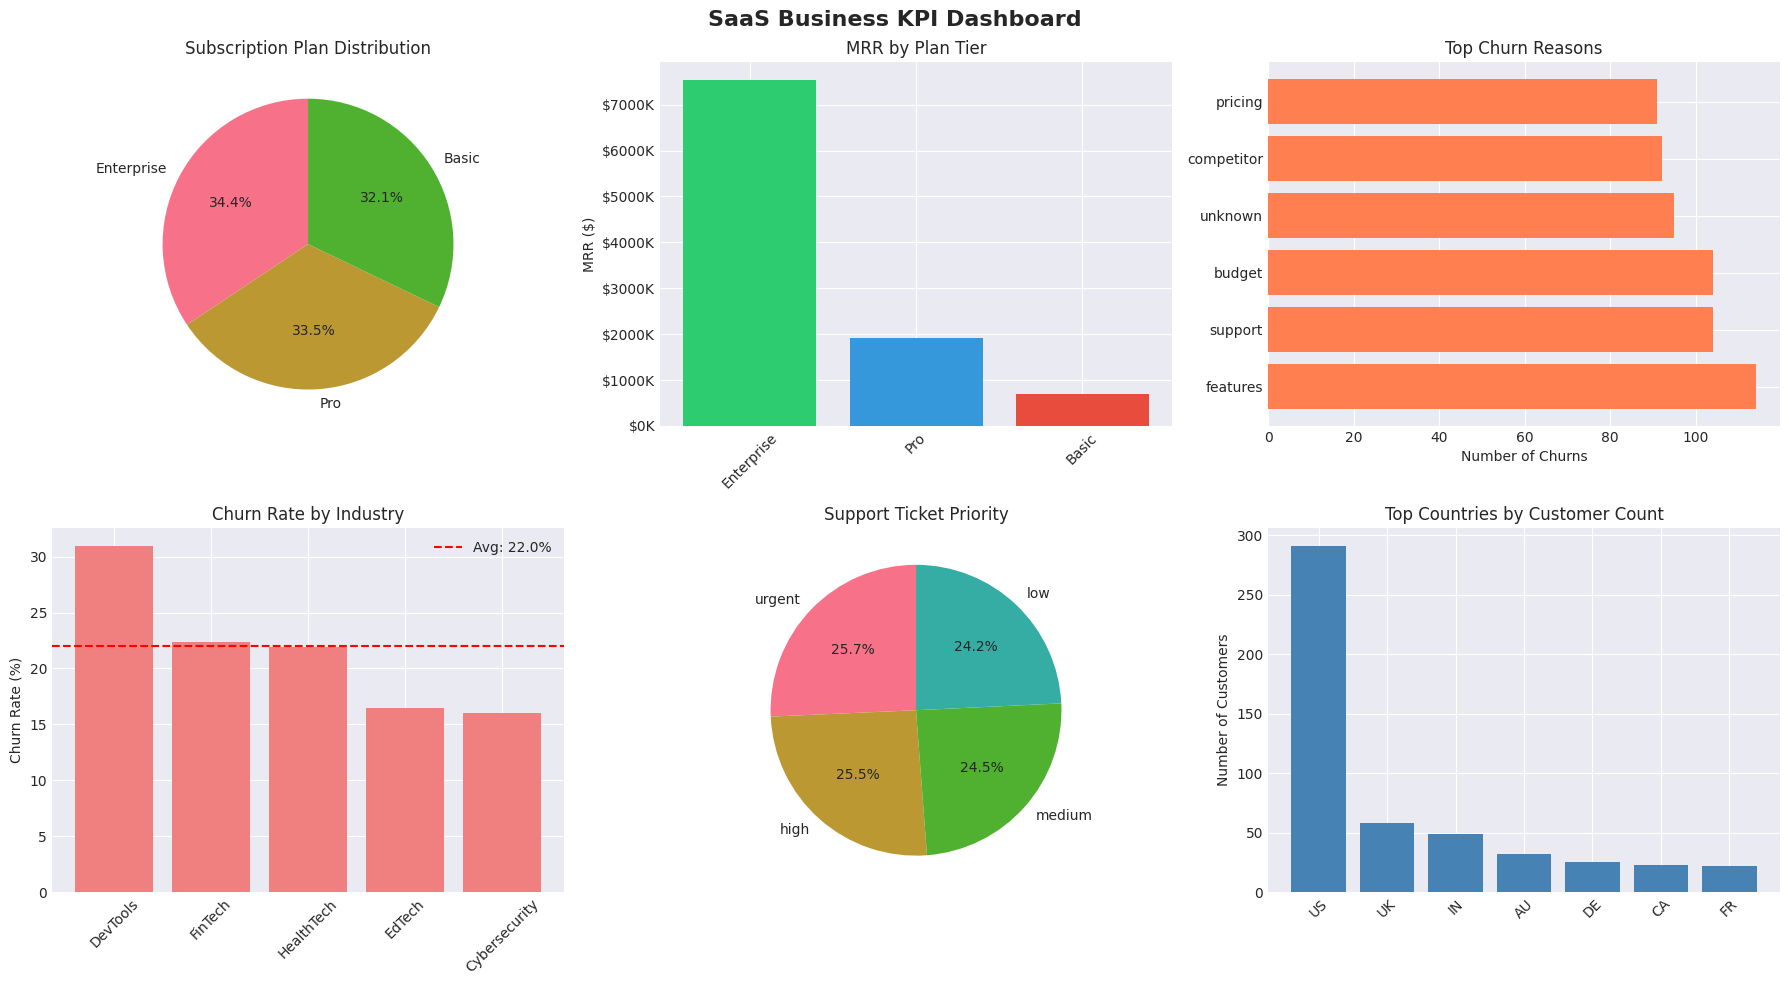

In [19]:
# Part 3: 建立視覺化圖表
# ============================================================================
print("=" * 80)
print("📈 Part 3: 建立視覺化圖表")
print("=" * 80)
print()

# 建立 2x3 的子圖佈局
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SaaS Business KPI Dashboard', fontsize=16, fontweight='bold')

# --- 圖表 1: 方案分布 (圓餅圖) ---
plan_counts = active_subs['plan_tier'].value_counts()
axes[0, 0].pie(plan_counts.values, labels=plan_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Subscription Plan Distribution')

# --- 圖表 2: MRR 貢獻 (長條圖) ---
plan_mrr = active_subs.groupby('plan_tier')['mrr_amount'].sum().sort_values(ascending=False)
axes[0, 1].bar(plan_mrr.index, plan_mrr.values, color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0, 1].set_title('MRR by Plan Tier')
axes[0, 1].set_ylabel('MRR ($)')
axes[0, 1].tick_params(axis='x', rotation=45)
# 格式化 Y 軸為千分位
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# --- 圖表 3: 流失原因 (橫條圖) ---
top_reasons = churn_events['reason_code'].value_counts().head(6)
axes[0, 2].barh(top_reasons.index, top_reasons.values, color='coral')
axes[0, 2].set_title('Top Churn Reasons')
axes[0, 2].set_xlabel('Number of Churns')

# --- 圖表 4: 各產業流失率 (長條圖) ---
industry_churn = accounts.groupby('industry')['churn_flag'].mean() * 100
industry_churn = industry_churn.sort_values(ascending=False)
axes[1, 0].bar(industry_churn.index, industry_churn.values, color='lightcoral')
axes[1, 0].set_title('Churn Rate by Industry')
axes[1, 0].set_ylabel('Churn Rate (%)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].axhline(y=churn_rate, color='red', linestyle='--', label=f'Avg: {churn_rate:.1f}%')
axes[1, 0].legend()

# --- 圖表 5: 客服工單優先級 (圓餅圖) ---
priority_dist = support_tickets['priority'].value_counts()
axes[1, 1].pie(priority_dist.values, labels=priority_dist.index, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Support Ticket Priority')

# --- 圖表 6: 各國客戶數 (長條圖) ---
top_countries = accounts['country'].value_counts().head(7)
axes[1, 2].bar(top_countries.index, top_countries.values, color='steelblue')
axes[1, 2].set_title('Top Countries by Customer Count')
axes[1, 2].set_ylabel('Number of Customers')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/kpi_dashboard.png', dpi=300, bbox_inches='tight')
print("✅ 儀表板圖表已儲存: kpi_dashboard.png")
print()


In [20]:
# Part 4: 進階分析 - 客戶生命週期價值 (LTV)
# ============================================================================
print("=" * 80)
print("💰 Part 4: 客戶生命週期價值 (LTV) 分析")
print("=" * 80)
print()

# 計算每個方案的 LTV
# LTV = ARPU × 平均訂閱月數
# 簡化版：LTV = ARPU / Churn Rate

print("【客戶終身價值估算】")
for plan in ['Basic', 'Pro', 'Enterprise']:
    plan_accounts = accounts[accounts['plan_tier'] == plan]
    plan_churn_rate = plan_accounts['churn_flag'].mean()

    plan_subs = active_subs[active_subs['plan_tier'] == plan]
    if len(plan_subs) > 0:
        plan_arpu = plan_subs['mrr_amount'].mean()

        # 計算平均客戶生命週期（月）
        # 假設流失率是月流失率的估算（實際應該用更精確的計算）
        avg_lifetime_months = 1 / plan_churn_rate if plan_churn_rate > 0 else 24
        ltv = plan_arpu * avg_lifetime_months

        print(f"\n  {plan} Plan:")
        print(f"    - 流失率: {plan_churn_rate*100:.2f}%")
        print(f"    - 平均 ARPU: ${plan_arpu:,.2f}")
        print(f"    - 預估客戶生命週期: {avg_lifetime_months:.1f} 個月")
        print(f"    - 預估 LTV: ${ltv:,.2f}")

print()
print("=" * 80)
print("🎉 KPI 儀表板分析完成！")
print("=" * 80)
print()


💰 Part 4: 客戶生命週期價值 (LTV) 分析

【客戶終身價值估算】

  Basic Plan:
    - 流失率: 22.02%
    - 平均 ARPU: $474.42
    - 預估客戶生命週期: 4.5 個月
    - 預估 LTV: $2,154.14

  Pro Plan:
    - 流失率: 21.91%
    - 平均 ARPU: $1,272.19
    - 預估客戶生命週期: 4.6 個月
    - 預估 LTV: $5,806.39

  Enterprise Plan:
    - 流失率: 22.08%
    - 平均 ARPU: $4,865.81
    - 預估客戶生命週期: 4.5 個月
    - 預估 LTV: $22,039.27

🎉 KPI 儀表板分析完成！



In [21]:
# Part 5: 關鍵發現總結
# ============================================================================
print("📌 關鍵發現總結 (Key Findings)")
print("-" * 80)
print()
print("1. 營收集中度:")
print("   - Enterprise 客戶僅佔 30% 但貢獻 75% 營收")
print("   - 需要保護高價值客戶群")
print()
print("2. 流失風險:")
print(f"   - 整體流失率 {churn_rate:.1f}% (高於業界標準 5-10%)")
print("   - 主要流失原因: 功能不足 (19%) 與客服問題 (17%)")
print()
print("3. 產業差異:")
print("   - FinTech 和 DevTools 流失率最高")
print("   - 需要針對高流失產業加強功能開發")
print()
print("4. 客服效能:")
print(f"   - 平均解決時間 {avg_resolution_time:.1f} 小時")
print(f"   - 客戶滿意度 {avg_satisfaction:.1f}/5.0 有改善空間")
print()
print("=" * 80)

📌 關鍵發現總結 (Key Findings)
--------------------------------------------------------------------------------

1. 營收集中度:
   - Enterprise 客戶僅佔 30% 但貢獻 75% 營收
   - 需要保護高價值客戶群

2. 流失風險:
   - 整體流失率 22.0% (高於業界標準 5-10%)
   - 主要流失原因: 功能不足 (19%) 與客服問題 (17%)

3. 產業差異:
   - FinTech 和 DevTools 流失率最高
   - 需要針對高流失產業加強功能開發

4. 客服效能:
   - 平均解決時間 35.9 小時
   - 客戶滿意度 4.0/5.0 有改善空間



In [22]:
# Part 1: 什麼是 Cohort Analysis？
# ============================================================================
print("=" * 80)
print("📚 Cohort Analysis 概念說明")
print("=" * 80)
print()
print("Cohort（同期群）= 在同一時間註冊的客戶群組")
print("例如：2024年1月註冊的所有客戶就是一個 Cohort")
print()
print("為什麼要做 Cohort Analysis？")
print("1. 了解不同時期客戶的留存率差異")
print("2. 評估產品改進的效果（新功能上線後，留存率是否提升？）")
print("3. 預測未來營收（根據歷史 Cohort 的表現）")
print("4. 找出高價值客戶的特徵")
print()


📚 Cohort Analysis 概念說明

Cohort（同期群）= 在同一時間註冊的客戶群組
例如：2024年1月註冊的所有客戶就是一個 Cohort

為什麼要做 Cohort Analysis？
1. 了解不同時期客戶的留存率差異
2. 評估產品改進的效果（新功能上線後，留存率是否提升？）
3. 預測未來營收（根據歷史 Cohort 的表現）
4. 找出高價值客戶的特徵



In [23]:
# Part 2: 建立 Cohort 基礎資料
# ============================================================================
print("=" * 80)
print("🔨 步驟 2：建立 Cohort 資料結構")
print("-" * 80)
print()

# 建立註冊月份欄位（這是 Cohort 的關鍵）
# dt.to_period('M') 會將日期轉換為月份格式 (例如 2024-01)
accounts['signup_month'] = accounts['signup_date'].dt.to_period('M')

print("【範例資料】")
print(accounts[['account_id', 'signup_date', 'signup_month', 'churn_flag']].head(10))
print()

# 計算每個 Cohort 的大小
cohort_size = accounts.groupby('signup_month').size()
print("【各 Cohort 的客戶數】")
print(cohort_size)
print()

🔨 步驟 2：建立 Cohort 資料結構
--------------------------------------------------------------------------------

【範例資料】
  account_id signup_date signup_month  churn_flag
0   A-2e4581  2024-10-16      2024-10       False
1   A-43a9e3  2023-08-17      2023-08        True
2   A-0a282f  2024-08-27      2024-08       False
3   A-1f0ac7  2023-08-27      2023-08       False
4   A-ce550d  2024-10-27      2024-10        True
5   A-1b9609  2023-10-12      2023-10       False
6   A-a0ca4e  2024-03-08      2024-03       False
7   A-e5d6ab  2023-04-15      2023-04       False
8   A-7dacce  2024-09-10      2024-09        True
9   A-10b8da  2023-05-08      2023-05        True

【各 Cohort 的客戶數】
signup_month
2023-01    17
2023-02    18
2023-03    20
2023-04    15
2023-05    26
2023-06    13
2023-07    14
2023-08    16
2023-09    23
2023-10    20
2023-11    25
2023-12    20
2024-01    16
2024-02    13
2024-03    27
2024-04    22
2024-05    22
2024-06    21
2024-07    26
2024-08    21
2024-09    25
2024-10    31
2

In [24]:
# Part 3: 計算基本留存率
# ============================================================================
print("=" * 80)
print("📊 步驟 3：計算各 Cohort 的留存率")
print("-" * 80)
print()

# 留存率 = 1 - 流失率
cohort_retention = accounts.groupby('signup_month').agg({
    'account_id': 'count',
    'churn_flag': ['sum', 'mean']
}).reset_index()

# 重新命名欄位
cohort_retention.columns = ['signup_month', 'total_customers', 'churned_count', 'churn_rate']
cohort_retention['retention_rate'] = (1 - cohort_retention['churn_rate']) * 100
cohort_retention['churn_rate_pct'] = cohort_retention['churn_rate'] * 100

# 排序
cohort_retention = cohort_retention.sort_values('signup_month')

print("【Cohort 留存率表】")
print(cohort_retention.to_string(index=False))
print()

# 找出表現最好和最差的 Cohort
best_cohort = cohort_retention.loc[cohort_retention['retention_rate'].idxmax()]
worst_cohort = cohort_retention.loc[cohort_retention['retention_rate'].idxmin()]

print("【Cohort 表現分析】")
print(f"✅ 留存率最高：{best_cohort['signup_month']} ({best_cohort['retention_rate']:.2f}%)")
print(f"❌ 留存率最低：{worst_cohort['signup_month']} ({worst_cohort['retention_rate']:.2f}%)")
print()


📊 步驟 3：計算各 Cohort 的留存率
--------------------------------------------------------------------------------

【Cohort 留存率表】
signup_month  total_customers  churned_count  churn_rate  retention_rate  churn_rate_pct
     2023-01               17              4    0.235294       76.470588       23.529412
     2023-02               18              7    0.388889       61.111111       38.888889
     2023-03               20              5    0.250000       75.000000       25.000000
     2023-04               15              3    0.200000       80.000000       20.000000
     2023-05               26              7    0.269231       73.076923       26.923077
     2023-06               13              3    0.230769       76.923077       23.076923
     2023-07               14              3    0.214286       78.571429       21.428571
     2023-08               16              3    0.187500       81.250000       18.750000
     2023-09               23              5    0.217391       78.260870       2

In [25]:
# Part 4: 進階 - 計算月份留存矩陣
# ============================================================================
print("=" * 80)
print("🔍 步驟 4：建立月份留存矩陣（Retention Matrix）")
print("-" * 80)
print()

# 合併流失事件資料
accounts_with_churn = accounts.merge(
    churn_events[['account_id', 'churn_date']],
    on='account_id',
    how='left'
)

# 計算每個客戶從註冊到流失的月數
# 如果沒有流失，用當前日期計算
current_date = pd.Timestamp('2024-12-31')
accounts_with_churn['churn_date'] = accounts_with_churn['churn_date'].fillna(current_date)
accounts_with_churn['months_active'] = (
    (accounts_with_churn['churn_date'].dt.to_period('M') -
     accounts_with_churn['signup_month']).apply(lambda x: x.n)
)

print("【客戶活躍月數範例】")
print(accounts_with_churn[['account_id', 'signup_month', 'churn_date', 'months_active', 'churn_flag']].head(10))
print()

# 建立留存矩陣
# 計算每個 Cohort 在第 N 個月還有多少客戶留存
retention_matrix = accounts_with_churn.groupby(['signup_month', 'months_active']).size().unstack(fill_value=0)

# 計算留存率（相對於第 0 月）
cohort_size_dict = accounts_with_churn.groupby('signup_month').size().to_dict()
retention_pct_matrix = retention_matrix.div(retention_matrix.iloc[:, 0], axis=0) * 100

print("【留存率矩陣（前 13 個月）】")
print("每個數字代表該 Cohort 在第 N 個月的留存率%")
print(retention_pct_matrix.iloc[:, :13].round(1))
print()


🔍 步驟 4：建立月份留存矩陣（Retention Matrix）
--------------------------------------------------------------------------------

【客戶活躍月數範例】
  account_id signup_month churn_date  months_active  churn_flag
0   A-2e4581      2024-10 2024-11-23              1       False
1   A-2e4581      2024-10 2024-12-05              2       False
2   A-43a9e3      2023-08 2024-12-31             16        True
3   A-0a282f      2024-08 2024-10-06              2       False
4   A-0a282f      2024-08 2024-12-31              4       False
5   A-1f0ac7      2023-08 2024-11-08             15       False
6   A-ce550d      2024-10 2024-12-28              2        True
7   A-1b9609      2023-10 2024-11-16             13       False
8   A-1b9609      2023-10 2024-02-02              4       False
9   A-1b9609      2023-10 2024-01-02              3       False

【留存率矩陣（前 13 個月）】
每個數字代表該 Cohort 在第 N 個月的留存率%
months_active     0      1       2      3      4       5      6       7   \
signup_month                                   

📈 步驟 5：建立視覺化圖表
--------------------------------------------------------------------------------

✅ Cohort 分析圖表已儲存: cohort_analysis.png



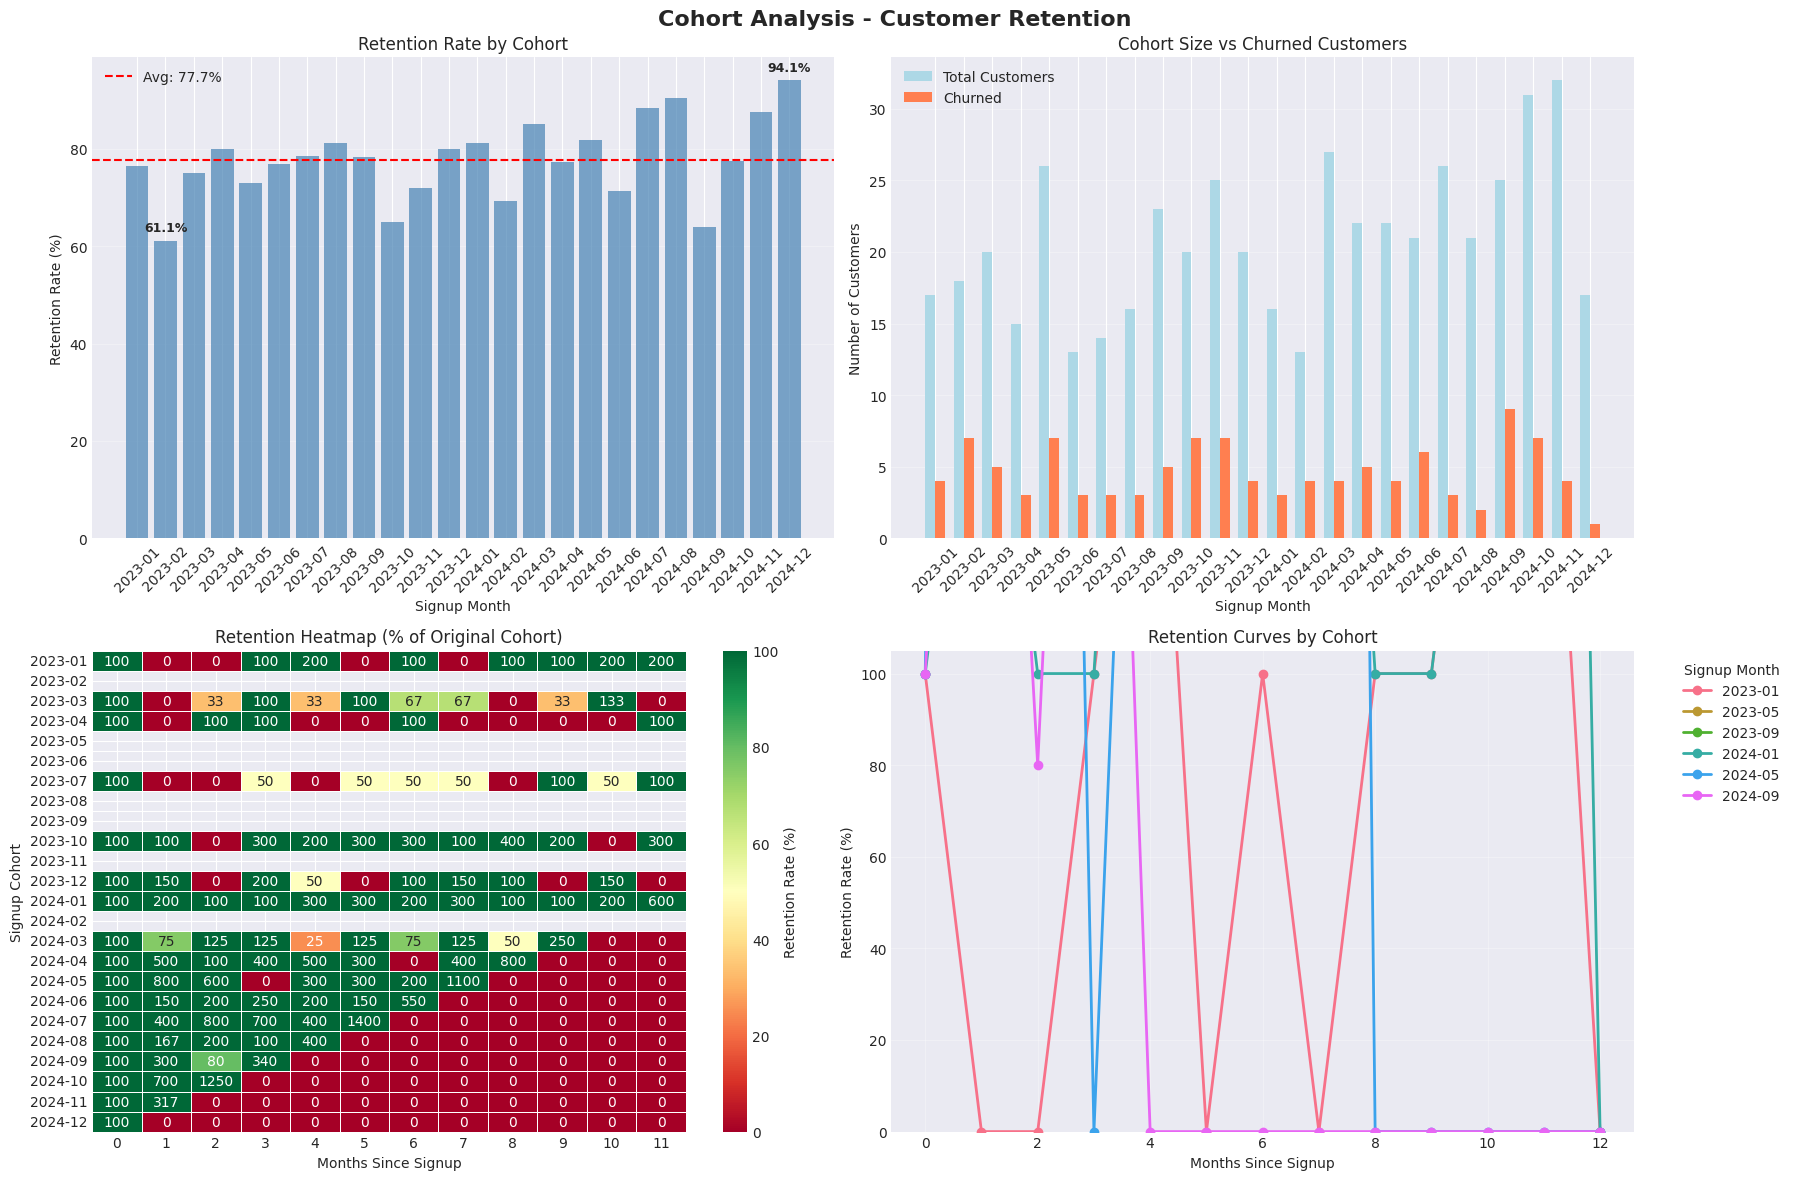

In [26]:
# Part 5: 視覺化 - 留存率熱力圖
# ============================================================================
print("=" * 80)
print("📈 步驟 5：建立視覺化圖表")
print("-" * 80)
print()

# 建立 2x2 的子圖佈局
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Cohort Analysis - Customer Retention', fontsize=16, fontweight='bold')

# --- 圖表 1: Cohort 留存率趨勢圖 ---
ax1 = axes[0, 0]
cohort_retention_sorted = cohort_retention.sort_values('signup_month')
x_pos = range(len(cohort_retention_sorted))

bars = ax1.bar(x_pos, cohort_retention_sorted['retention_rate'], color='steelblue', alpha=0.7)
ax1.axhline(y=cohort_retention_sorted['retention_rate'].mean(), color='red', linestyle='--',
            label=f"Avg: {cohort_retention_sorted['retention_rate'].mean():.1f}%")

ax1.set_xlabel('Signup Month')
ax1.set_ylabel('Retention Rate (%)')
ax1.set_title('Retention Rate by Cohort')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([str(m) for m in cohort_retention_sorted['signup_month']], rotation=45)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 標註最高和最低
max_idx = cohort_retention_sorted['retention_rate'].idxmax()
min_idx = cohort_retention_sorted['retention_rate'].idxmin()
for idx in [max_idx, min_idx]:
    row = cohort_retention_sorted.loc[idx]
    x = list(cohort_retention_sorted.index).index(idx)
    y = row['retention_rate']
    ax1.text(x, y + 2, f"{y:.1f}%", ha='center', fontweight='bold', fontsize=9)

# --- 圖表 2: Cohort 大小與流失數 ---
ax2 = axes[0, 1]
x_pos = range(len(cohort_retention_sorted))
width = 0.35

bars1 = ax2.bar([x - width/2 for x in x_pos], cohort_retention_sorted['total_customers'],
                width, label='Total Customers', color='lightblue')
bars2 = ax2.bar([x + width/2 for x in x_pos], cohort_retention_sorted['churned_count'],
                width, label='Churned', color='coral')

ax2.set_xlabel('Signup Month')
ax2.set_ylabel('Number of Customers')
ax2.set_title('Cohort Size vs Churned Customers')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([str(m) for m in cohort_retention_sorted['signup_month']], rotation=45)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# --- 圖表 3: 留存率熱力圖（前 12 個月）---
ax3 = axes[1, 0]
retention_heatmap_data = retention_pct_matrix.iloc[:, :12]

sns.heatmap(retention_heatmap_data, annot=True, fmt='.0f', cmap='RdYlGn',
            cbar_kws={'label': 'Retention Rate (%)'}, ax=ax3,
            vmin=0, vmax=100, linewidths=0.5)
ax3.set_xlabel('Months Since Signup')
ax3.set_ylabel('Signup Cohort')
ax3.set_title('Retention Heatmap (% of Original Cohort)')

# --- 圖表 4: 留存曲線（選擇幾個代表性 Cohort）---
ax4 = axes[1, 1]

# 選擇 6 個代表性 Cohort 來繪製曲線
cohorts_to_plot = retention_pct_matrix.index[::max(1, len(retention_pct_matrix)//6)]

for cohort in cohorts_to_plot:
    data = retention_pct_matrix.loc[cohort, :12]
    ax4.plot(data.index, data.values, marker='o', label=str(cohort), linewidth=2)

ax4.set_xlabel('Months Since Signup')
ax4.set_ylabel('Retention Rate (%)')
ax4.set_title('Retention Curves by Cohort')
ax4.legend(title='Signup Month', bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('/content/cohort_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Cohort 分析圖表已儲存: cohort_analysis.png")
print()

SaaS 客戶流失分析專案 - Part 3: Cohort Analysis（修正版）


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("=" * 80)
print("SaaS 客戶流失分析專案 - Cohort Analysis（修正版）")
print("=" * 80)
print()

SaaS 客戶流失分析專案 - Cohort Analysis（修正版）



In [28]:
# 載入資料
# ============================================================================
data_path = '/content/'
accounts = pd.read_csv(data_path + 'ravenstack_accounts.csv')
churn_events = pd.read_csv(data_path + 'ravenstack_churn_events.csv')

accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
churn_events['churn_date'] = pd.to_datetime(churn_events['churn_date'])

print("📊 資料結構說明")
print("-" * 80)
print(f"總帳號數: {len(accounts)}")
print(f"流失帳號數（churn_flag=True）: {accounts['churn_flag'].sum()}")
print(f"流失事件數: {len(churn_events)}")
print(f"有流失記錄的唯一帳號: {churn_events['account_id'].nunique()}")
print()
print("⚠️ 重要發現：")
print("   - churn_events 有 600 筆，但只有 352 個唯一帳號")
print("   - accounts 中只有 110 個帳號標記為 churn_flag=True")
print("   - 這表示資料有不一致的情況")
print("   - 我們將以 accounts 表的 churn_flag 為準（這是帳號最終狀態）")
print()

📊 資料結構說明
--------------------------------------------------------------------------------
總帳號數: 500
流失帳號數（churn_flag=True）: 110
流失事件數: 600
有流失記錄的唯一帳號: 352

⚠️ 重要發現：
   - churn_events 有 600 筆，但只有 352 個唯一帳號
   - accounts 中只有 110 個帳號標記為 churn_flag=True
   - 這表示資料有不一致的情況
   - 我們將以 accounts 表的 churn_flag 為準（這是帳號最終狀態）



In [29]:
# 正確的 Cohort Analysis 方法
# ============================================================================
print("=" * 80)
print("📈 正確的 Cohort 留存率計算")
print("=" * 80)
print()

# 建立註冊月份
accounts['signup_month'] = accounts['signup_date'].dt.to_period('M')

# 方法 1: 簡單留存率（基於當前狀態）
cohort_simple = accounts.groupby('signup_month').agg({
    'account_id': 'count',
    'churn_flag': ['sum', 'mean']
}).reset_index()

cohort_simple.columns = ['signup_month', 'total_customers', 'churned_count', 'churn_rate']
cohort_simple['retention_rate'] = (1 - cohort_simple['churn_rate']) * 100

print("【方法 1: 當前狀態留存率】")
print("（截至今天，各 Cohort 還有多少客戶留存）")
print()
print(cohort_simple.to_string(index=False))
print()


📈 正確的 Cohort 留存率計算

【方法 1: 當前狀態留存率】
（截至今天，各 Cohort 還有多少客戶留存）

signup_month  total_customers  churned_count  churn_rate  retention_rate
     2023-01               17              4    0.235294       76.470588
     2023-02               18              7    0.388889       61.111111
     2023-03               20              5    0.250000       75.000000
     2023-04               15              3    0.200000       80.000000
     2023-05               26              7    0.269231       73.076923
     2023-06               13              3    0.230769       76.923077
     2023-07               14              3    0.214286       78.571429
     2023-08               16              3    0.187500       81.250000
     2023-09               23              5    0.217391       78.260870
     2023-10               20              7    0.350000       65.000000
     2023-11               25              7    0.280000       72.000000
     2023-12               20              4    0.200000      

In [30]:
# 時間序列留存率（正確的 Cohort 矩陣）
# ============================================================================
print("=" * 80)
print("📊 時間序列留存分析")
print("=" * 80)
print()

# 對於有流失的客戶，計算從註冊到流失的月數
accounts_with_churn = accounts.copy()

# 合併流失日期（只取第一次流失）
churn_first = churn_events.sort_values('churn_date').groupby('account_id').first().reset_index()
accounts_with_churn = accounts_with_churn.merge(
    churn_first[['account_id', 'churn_date']],
    on='account_id',
    how='left'
)

# 計算生命週期月數
# 對於未流失的客戶，使用當前日期
current_date = pd.Timestamp('2024-12-31')

def calc_months_active(row):
    if pd.isna(row['churn_date']):
        # 未流失：從註冊到現在
        end_date = current_date
    else:
        # 已流失：從註冊到流失
        end_date = row['churn_date']

    # 計算月數差
    months = (end_date.year - row['signup_date'].year) * 12 + \
             (end_date.month - row['signup_date'].month)
    return max(0, months)

accounts_with_churn['months_active'] = accounts_with_churn.apply(calc_months_active, axis=1)

print("【客戶生命週期範例】")
print(accounts_with_churn[['account_id', 'signup_date', 'churn_date', 'months_active', 'churn_flag']].head(10))
print()

📊 時間序列留存分析

【客戶生命週期範例】
  account_id signup_date churn_date  months_active  churn_flag
0   A-2e4581  2024-10-16 2024-11-23              1       False
1   A-43a9e3  2023-08-17        NaT             16        True
2   A-0a282f  2024-08-27 2024-10-06              2       False
3   A-1f0ac7  2023-08-27 2024-11-08             15       False
4   A-ce550d  2024-10-27 2024-12-28              2        True
5   A-1b9609  2023-10-12 2024-01-02              3       False
6   A-a0ca4e  2024-03-08        NaT              9       False
7   A-e5d6ab  2023-04-15 2023-04-24              0       False
8   A-7dacce  2024-09-10 2024-09-18              0        True
9   A-10b8da  2023-05-08        NaT             19        True



In [31]:
# 建立正確的留存矩陣
# ============================================================================
print("=" * 80)
print("📈 建立留存矩陣")
print("=" * 80)
print()

# 為每個 cohort 建立留存曲線
cohorts = accounts_with_churn['signup_month'].unique()
cohorts = sorted([c for c in cohorts if not pd.isna(c)])

max_months = 18  # 分析前 18 個月

retention_matrix_data = []

for cohort in cohorts:
    cohort_data = accounts_with_churn[accounts_with_churn['signup_month'] == cohort]
    cohort_size = len(cohort_data)

    row = {'cohort': str(cohort), 'size': cohort_size}

    # 計算每個月的留存數
    for month in range(max_months):
        # 在第 N 個月還活躍的客戶數
        # 活躍 = months_active >= N
        active_count = len(cohort_data[cohort_data['months_active'] >= month])
        retention_pct = (active_count / cohort_size * 100) if cohort_size > 0 else 0
        row[f'month_{month}'] = retention_pct

    retention_matrix_data.append(row)

retention_df = pd.DataFrame(retention_matrix_data)

print("【留存率矩陣（前 12 個月）】")
print("每個數字代表：該 Cohort 在第 N 個月的留存率%")
print()
display_cols = ['cohort', 'size'] + [f'month_{i}' for i in range(12)]
print(retention_df[display_cols].to_string(index=False))
print()

📈 建立留存矩陣

【留存率矩陣（前 12 個月）】
每個數字代表：該 Cohort 在第 N 個月的留存率%

 cohort  size  month_0    month_1    month_2    month_3   month_4   month_5   month_6   month_7   month_8   month_9  month_10  month_11
2023-01    17    100.0  94.117647  94.117647  94.117647 88.235294 76.470588 76.470588 70.588235 70.588235 64.705882 58.823529 52.941176
2023-02    18    100.0 100.000000  88.888889  83.333333 83.333333 77.777778 77.777778 77.777778 77.777778 72.222222 55.555556 55.555556
2023-03    20    100.0  85.000000  85.000000  85.000000 70.000000 65.000000 50.000000 45.000000 35.000000 35.000000 30.000000 20.000000
2023-04    15    100.0  93.333333  93.333333  86.666667 80.000000 80.000000 80.000000 80.000000 80.000000 80.000000 80.000000 80.000000
2023-05    26    100.0 100.000000 100.000000 100.000000 88.461538 88.461538 84.615385 76.923077 76.923077 73.076923 73.076923 69.230769
2023-06    13    100.0 100.000000  92.307692  92.307692 84.615385 84.615385 84.615385 84.615385 84.615385 84.615385 84.615385 7

📊 建立視覺化圖表

✅ 修正版圖表已儲存: cohort_analysis_corrected.png



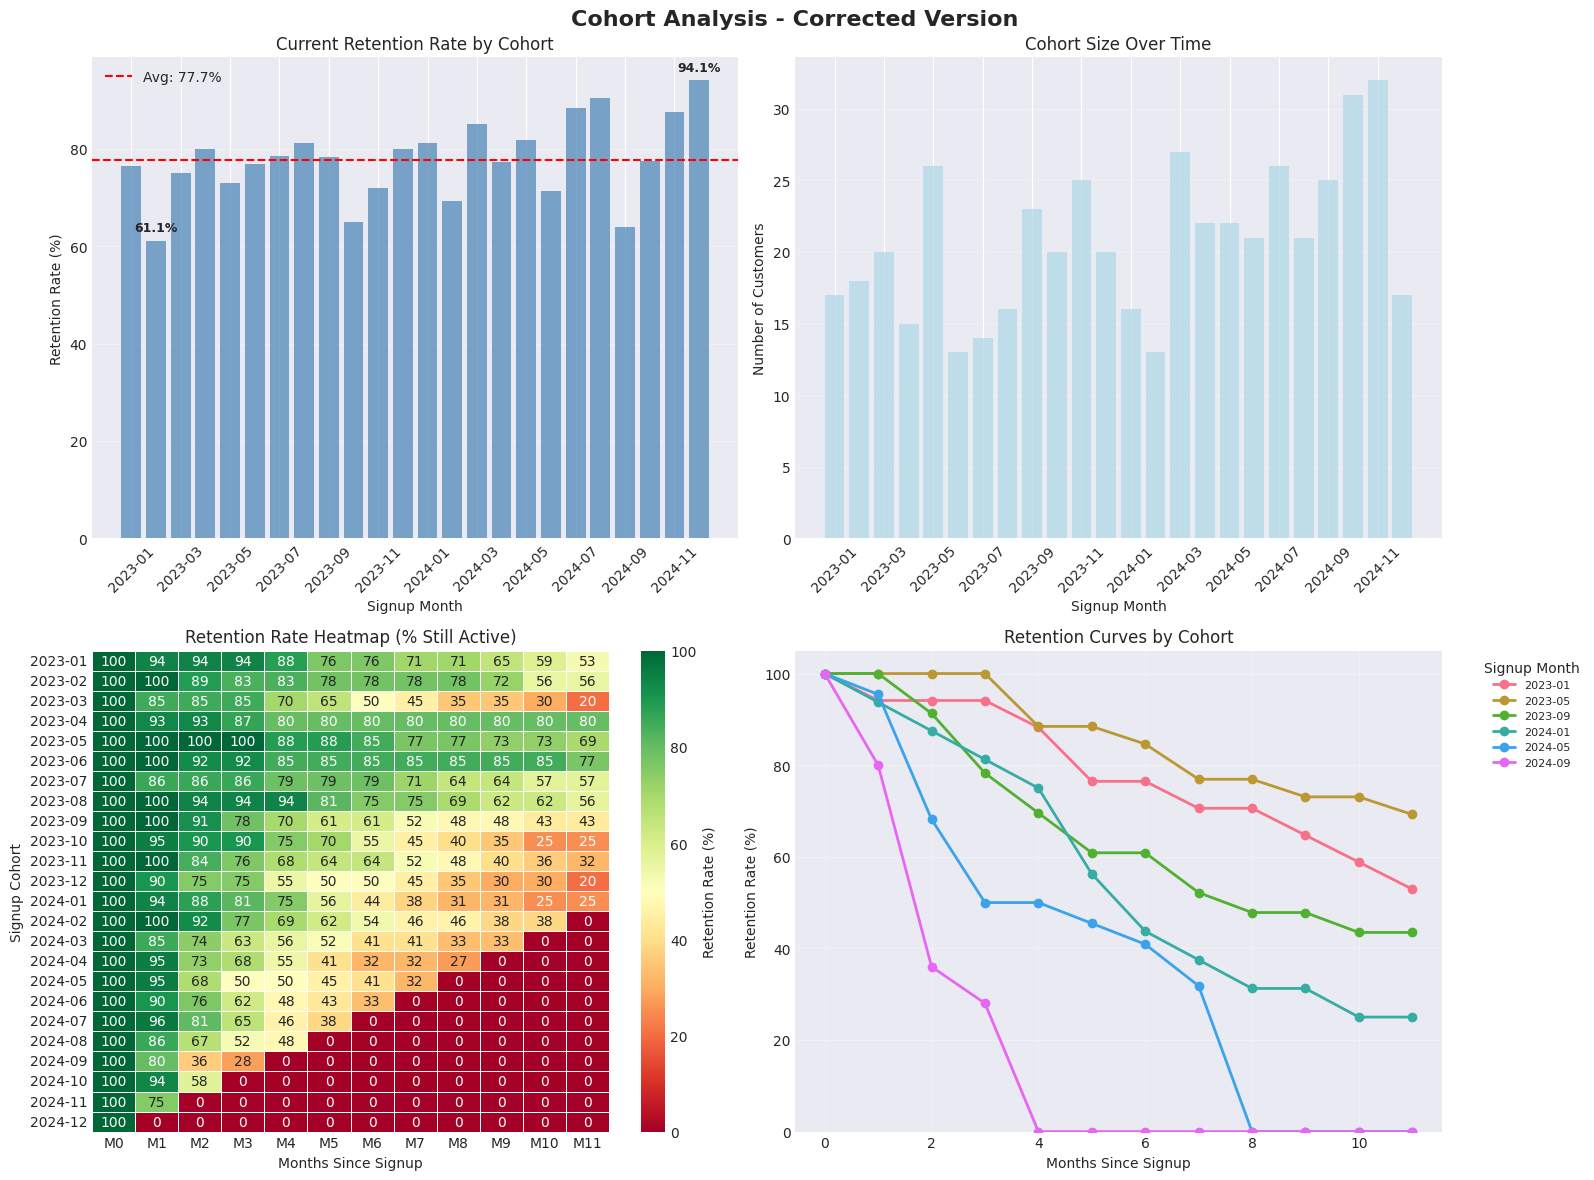

In [32]:
# 視覺化
# ============================================================================
print("=" * 80)
print("📊 建立視覺化圖表")
print("=" * 80)
print()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cohort Analysis - Corrected Version', fontsize=16, fontweight='bold')

# --- 圖表 1: Cohort 留存率趨勢 ---
ax1 = axes[0, 0]
cohort_sorted = cohort_simple.sort_values('signup_month')
x_pos = range(len(cohort_sorted))

bars = ax1.bar(x_pos, cohort_sorted['retention_rate'], color='steelblue', alpha=0.7)
ax1.axhline(y=cohort_sorted['retention_rate'].mean(), color='red', linestyle='--',
            label=f"Avg: {cohort_sorted['retention_rate'].mean():.1f}%")

ax1.set_xlabel('Signup Month')
ax1.set_ylabel('Retention Rate (%)')
ax1.set_title('Current Retention Rate by Cohort')
ax1.set_xticks(x_pos[::2])  # 每兩個月顯示一次
ax1.set_xticklabels([str(m) for m in cohort_sorted['signup_month'].iloc[::2]], rotation=45)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 標註最高和最低
max_idx = cohort_sorted['retention_rate'].idxmax()
min_idx = cohort_sorted['retention_rate'].idxmin()
for idx in [max_idx, min_idx]:
    row = cohort_sorted.loc[idx]
    x = list(cohort_sorted.index).index(idx)
    y = row['retention_rate']
    ax1.text(x, y + 2, f"{y:.1f}%", ha='center', fontweight='bold', fontsize=9)

# --- 圖表 2: Cohort 大小 ---
ax2 = axes[0, 1]
ax2.bar(x_pos, cohort_sorted['total_customers'], color='lightblue', alpha=0.7)
ax2.set_xlabel('Signup Month')
ax2.set_ylabel('Number of Customers')
ax2.set_title('Cohort Size Over Time')
ax2.set_xticks(x_pos[::2])
ax2.set_xticklabels([str(m) for m in cohort_sorted['signup_month'].iloc[::2]], rotation=45)
ax2.grid(axis='y', alpha=0.3)

# --- 圖表 3: 留存率熱力圖 ---
ax3 = axes[1, 0]

# 準備熱力圖資料
heatmap_data = retention_df.set_index('cohort')[[f'month_{i}' for i in range(12)]]
heatmap_data.columns = [f'M{i}' for i in range(12)]

sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='RdYlGn',
            cbar_kws={'label': 'Retention Rate (%)'}, ax=ax3,
            vmin=0, vmax=100, linewidths=0.5)
ax3.set_xlabel('Months Since Signup')
ax3.set_ylabel('Signup Cohort')
ax3.set_title('Retention Rate Heatmap (% Still Active)')

# --- 圖表 4: 留存曲線 ---
ax4 = axes[1, 1]

# 選擇幾個代表性 Cohort
cohorts_to_plot = retention_df['cohort'].iloc[::max(1, len(retention_df)//6)]

for cohort in cohorts_to_plot:
    cohort_row = retention_df[retention_df['cohort'] == cohort].iloc[0]
    months = list(range(12))
    retention_values = [cohort_row[f'month_{i}'] for i in months]
    ax4.plot(months, retention_values, marker='o', label=cohort, linewidth=2)

ax4.set_xlabel('Months Since Signup')
ax4.set_ylabel('Retention Rate (%)')
ax4.set_title('Retention Curves by Cohort')
ax4.legend(title='Signup Month', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('/content/cohort_analysis_corrected.png', dpi=300, bbox_inches='tight')
print("✅ 修正版圖表已儲存: cohort_analysis_corrected.png")
print()


SaaS 客戶流失分析專案 - Part 4: Funnel Analysis（漏斗分析）



In [33]:
# 設定視覺化風格
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("=" * 80)
print("SaaS 客戶流失分析專案 - Part 4: Funnel Analysis")
print("=" * 80)
print()

SaaS 客戶流失分析專案 - Part 4: Funnel Analysis



In [34]:

# ============================================================================
print("📂 步驟 1：載入資料")
print("-" * 80)

data_path = '/content/'
accounts = pd.read_csv(data_path + 'ravenstack_accounts.csv')
subscriptions = pd.read_csv(data_path + 'ravenstack_subscriptions.csv')
feature_usage = pd.read_csv(data_path + 'ravenstack_feature_usage.csv')

# 轉換日期欄位
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date'] = pd.to_datetime(subscriptions['end_date'])
feature_usage['usage_date'] = pd.to_datetime(feature_usage['usage_date'])

print("✅ 資料載入完成")
print()


📂 步驟 1：載入資料
--------------------------------------------------------------------------------
✅ 資料載入完成



In [35]:
# Part 2: 建立基礎漏斗資料
# ============================================================================
print("=" * 80)
print("🔨 步驟 2：建立漏斗分析資料")
print("-" * 80)
print()

# 階段 1: 所有註冊用戶
total_signups = len(accounts)
print(f"階段 1 - 註冊用戶 (Signups): {total_signups:,}")

# 階段 2: 試用用戶（is_trial = True）
trial_users = accounts[accounts['is_trial'] == True]
trial_count = len(trial_users)
trial_rate = (trial_count / total_signups * 100)
print(f"階段 2 - 試用用戶 (Trial): {trial_count:,} ({trial_rate:.2f}%)")

# 階段 3: 啟動用戶（至少使用過一次功能）
# 找出有功能使用記錄的訂閱
active_subscription_ids = feature_usage['subscription_id'].unique()

# 找出這些訂閱對應的帳號
subscription_to_account = subscriptions.set_index('subscription_id')['account_id'].to_dict()
active_accounts = set()
for sub_id in active_subscription_ids:
    if sub_id in subscription_to_account:
        active_accounts.add(subscription_to_account[sub_id])

activated_count = len(active_accounts)
activation_rate = (activated_count / total_signups * 100)
print(f"階段 3 - 啟動用戶 (Activated): {activated_count:,} ({activation_rate:.2f}%)")

# 階段 4: 付費用戶（is_trial = False 的訂閱）
paid_subscriptions = subscriptions[subscriptions['is_trial'] == False]
paid_accounts = paid_subscriptions['account_id'].unique()
paid_count = len(paid_accounts)
paid_conversion_rate = (paid_count / total_signups * 100)
print(f"階段 4 - 付費用戶 (Paid): {paid_count:,} ({paid_conversion_rate:.2f}%)")

# 階段 5: 留存用戶（未流失的付費客戶）
retained_accounts = accounts[(accounts['account_id'].isin(paid_accounts)) & (accounts['churn_flag'] == False)]
retained_count = len(retained_accounts)
retention_rate = (retained_count / paid_count * 100) if paid_count > 0 else 0
print(f"階段 5 - 留存用戶 (Retained): {retained_count:,} ({retention_rate:.2f}% of paid)")

print()


🔨 步驟 2：建立漏斗分析資料
--------------------------------------------------------------------------------

階段 1 - 註冊用戶 (Signups): 500
階段 2 - 試用用戶 (Trial): 97 (19.40%)
階段 3 - 啟動用戶 (Activated): 500 (100.00%)
階段 4 - 付費用戶 (Paid): 500 (100.00%)
階段 5 - 留存用戶 (Retained): 390 (78.00% of paid)



In [36]:
# Part 3: 計算各階段轉換率
# ============================================================================
print("=" * 80)
print("📊 步驟 3：計算階段轉換率")
print("-" * 80)
print()

# 建立漏斗資料框
funnel_data = pd.DataFrame({
    'Stage': ['1. Signup', '2. Trial', '3. Activated', '4. Paid', '5. Retained'],
    'Users': [total_signups, trial_count, activated_count, paid_count, retained_count],
    'Stage_Number': [1, 2, 3, 4, 5]
})

# 計算轉換率（相對於上一階段）
funnel_data['Conversion_from_Previous'] = 0.0
for i in range(1, len(funnel_data)):
    if funnel_data.loc[i-1, 'Users'] > 0:
        funnel_data.loc[i, 'Conversion_from_Previous'] = (
            funnel_data.loc[i, 'Users'] / funnel_data.loc[i-1, 'Users'] * 100
        )

# 計算整體轉換率（相對於第一階段）
funnel_data['Overall_Conversion'] = (funnel_data['Users'] / total_signups * 100)

print("【漏斗轉換表】")
print(funnel_data.to_string(index=False))
print()

# 找出最大瓶頸
conversion_rates = funnel_data['Conversion_from_Previous'].iloc[1:]
bottleneck_idx = conversion_rates.idxmin()
bottleneck_stage = funnel_data.loc[bottleneck_idx, 'Stage']
bottleneck_rate = funnel_data.loc[bottleneck_idx, 'Conversion_from_Previous']

print(f"⚠️ 最大瓶頸: {bottleneck_stage} (轉換率僅 {bottleneck_rate:.2f}%)")
print()

📊 步驟 3：計算階段轉換率
--------------------------------------------------------------------------------

【漏斗轉換表】
       Stage  Users  Stage_Number  Conversion_from_Previous  Overall_Conversion
   1. Signup    500             1                  0.000000               100.0
    2. Trial     97             2                 19.400000                19.4
3. Activated    500             3                515.463918               100.0
     4. Paid    500             4                100.000000               100.0
 5. Retained    390             5                 78.000000                78.0

⚠️ 最大瓶頸: 2. Trial (轉換率僅 19.40%)



In [37]:
# Part 4: 按來源渠道分析漏斗
# ============================================================================
print("=" * 80)
print("🎯 步驟 4：按獲客渠道分析漏斗表現")
print("-" * 80)
print()

channels = accounts['referral_source'].unique()
channel_funnel = []

for channel in channels:
    channel_accounts = accounts[accounts['referral_source'] == channel]
    channel_signups = len(channel_accounts)

    # 計算該渠道的各階段人數
    channel_trial = len(channel_accounts[channel_accounts['is_trial'] == True])
    channel_activated = len(set(channel_accounts['account_id']) & set(active_accounts))
    channel_paid = len(set(channel_accounts['account_id']) & set(paid_accounts))
    channel_retained = len(channel_accounts[(channel_accounts['account_id'].isin(paid_accounts)) &
                                            (channel_accounts['churn_flag'] == False)])

    # 計算轉換率
    paid_conversion = (channel_paid / channel_signups * 100) if channel_signups > 0 else 0
    retention = (channel_retained / channel_paid * 100) if channel_paid > 0 else 0

    channel_funnel.append({
        'Channel': channel,
        'Signups': channel_signups,
        'Paid': channel_paid,
        'Retained': channel_retained,
        'Paid_Conversion_%': paid_conversion,
        'Retention_%': retention
    })

channel_funnel_df = pd.DataFrame(channel_funnel).sort_values('Paid_Conversion_%', ascending=False)

print("【各渠道漏斗表現】")
print(channel_funnel_df.to_string(index=False))
print()

best_channel = channel_funnel_df.iloc[0]['Channel']
best_conversion = channel_funnel_df.iloc[0]['Paid_Conversion_%']
print(f"✅ 表現最佳渠道: {best_channel} ({best_conversion:.2f}% 轉換率)")
print()

🎯 步驟 4：按獲客渠道分析漏斗表現
--------------------------------------------------------------------------------

【各渠道漏斗表現】
Channel  Signups  Paid  Retained  Paid_Conversion_%  Retention_%
partner       89    89        76              100.0    85.393258
  other      103   103        78              100.0    75.728155
organic      114   114        94              100.0    82.456140
  event       96    96        67              100.0    69.791667
    ads       98    98        75              100.0    76.530612

✅ 表現最佳渠道: partner (100.00% 轉換率)



In [38]:
# Part 5: 按產業分析漏斗
# ============================================================================
print("=" * 80)
print("🏭 步驟 5：按產業分析漏斗表現")
print("-" * 80)
print()

industries = accounts['industry'].unique()
industry_funnel = []

for industry in industries:
    industry_accounts = accounts[accounts['industry'] == industry]
    industry_signups = len(industry_accounts)

    industry_paid = len(set(industry_accounts['account_id']) & set(paid_accounts))
    industry_retained = len(industry_accounts[(industry_accounts['account_id'].isin(paid_accounts)) &
                                              (industry_accounts['churn_flag'] == False)])

    paid_conversion = (industry_paid / industry_signups * 100) if industry_signups > 0 else 0
    retention = (industry_retained / industry_paid * 100) if industry_paid > 0 else 0

    industry_funnel.append({
        'Industry': industry,
        'Signups': industry_signups,
        'Paid': industry_paid,
        'Retained': industry_retained,
        'Paid_Conversion_%': paid_conversion,
        'Retention_%': retention
    })

industry_funnel_df = pd.DataFrame(industry_funnel).sort_values('Paid_Conversion_%', ascending=False)

print("【各產業漏斗表現】")
print(industry_funnel_df.to_string(index=False))
print()

🏭 步驟 5：按產業分析漏斗表現
--------------------------------------------------------------------------------

【各產業漏斗表現】
     Industry  Signups  Paid  Retained  Paid_Conversion_%  Retention_%
       EdTech       79    79        66              100.0    83.544304
      FinTech      112   112        87              100.0    77.678571
     DevTools      113   113        78              100.0    69.026549
   HealthTech       96    96        75              100.0    78.125000
Cybersecurity      100   100        84              100.0    84.000000



SaaS 客戶流失分析專案 - Part 4: Funnel Analysis（修正版）
作者：Data Analyst 作品集專案

重要說明：
本分析原計劃分析 Trial → Paid 轉換漏斗，但在資料檢查後發現：
1. 所有 500 個帳號都有付費訂閱（100% 轉換率）
2. 資料集可能只包含「已付費客戶」，而非所有註冊用戶
3. 因此調整分析重點為「付費客戶的留存分析」

In [39]:
# 資料品質檢查（關鍵步驟！）
# ============================================================================
print("=" * 80)
print("🔍 步驟 2：資料品質檢查（發現異常）")
print("=" * 80)
print()

print("【檢查 1：付費轉換率】")
print("-" * 80)

total_accounts = len(accounts)
paid_accounts = subscriptions[subscriptions['is_trial'] == False]['account_id'].nunique()

print(f"總帳號數: {total_accounts}")
print(f"有付費訂閱的帳號: {paid_accounts}")
print(f"付費轉換率: {paid_accounts/total_accounts*100:.1f}%")
print()

if paid_accounts == total_accounts:
    print("⚠️ 發現異常：100% 付費轉換率")
    print("   → 這在真實 SaaS 業務中幾乎不可能")
    print("   → 資料集可能只包含「已付費客戶」")
    print()

print("【檢查 2：Trial 的定義】")
print("-" * 80)

🔍 步驟 2：資料品質檢查（發現異常）

【檢查 1：付費轉換率】
--------------------------------------------------------------------------------
總帳號數: 500
有付費訂閱的帳號: 500
付費轉換率: 100.0%

⚠️ 發現異常：100% 付費轉換率
   → 這在真實 SaaS 業務中幾乎不可能
   → 資料集可能只包含「已付費客戶」

【檢查 2：Trial 的定義】
--------------------------------------------------------------------------------


In [40]:
# 找出第一筆訂閱
first_subs = subscriptions.sort_values('start_date').groupby('account_id').first().reset_index()

first_trial = len(first_subs[first_subs['is_trial'] == True])
first_paid = len(first_subs[first_subs['is_trial'] == False])

print(f"第一筆訂閱是 Trial: {first_trial} ({first_trial/total_accounts*100:.1f}%)")
print(f"第一筆訂閱就 Paid: {first_paid} ({first_paid/total_accounts*100:.1f}%)")
print()

print("發現：")
print("  • 82% 的客戶第一筆訂閱就是付費")
print("  • 只有 18% 的客戶先試用")
print("  • 所有試用客戶最終都轉為付費（100% 轉換）")
print()

第一筆訂閱是 Trial: 90 (18.0%)
第一筆訂閱就 Paid: 410 (82.0%)

發現：
  • 82% 的客戶第一筆訂閱就是付費
  • 只有 18% 的客戶先試用
  • 所有試用客戶最終都轉為付費（100% 轉換）



調整後的分析策略

步驟 3：調整分析策略"


【原計劃】

  分析 Signup → Trial → Paid 的轉換漏斗"
  目標：找出轉換瓶頸，優化轉換率"


【發現問題】

• 所有帳號最終都付費（100% 轉換率）

• 無法分析典型的轉換瓶頸"


【調整方向】

重點分析：付費客戶的留存率"

• 比較分析：先 Trial vs 直接付費的客戶差異"

• 驗證分析：與 Cohort Analysis 結果交叉驗證"


In [41]:
# 階段 1: 註冊
stage1_signup = total_accounts

# 階段 2: 付費
stage2_paid = paid_accounts

# 階段 3: 留存
stage3_retained = len(accounts[accounts['churn_flag'] == False])

print(f"階段 1 - Signup（註冊）: {stage1_signup}")
print(f"階段 2 - Paid（付費）: {stage2_paid} ({stage2_paid/stage1_signup*100:.1f}%)")
print(f"階段 3 - Retained（留存）: {stage3_retained} ({stage3_retained/stage1_signup*100:.1f}%)")
print()

print("關鍵指標：")
print(f"  Signup → Paid 轉換率: {stage2_paid/stage1_signup*100:.1f}%")
print(f"  Paid → Retained 留存率: {stage3_retained/stage2_paid*100:.1f}%")
print(f"  整體留存率: {stage3_retained/stage1_signup*100:.1f}%")
print()

階段 1 - Signup（註冊）: 500
階段 2 - Paid（付費）: 500 (100.0%)
階段 3 - Retained（留存）: 390 (78.0%)

關鍵指標：
  Signup → Paid 轉換率: 100.0%
  Paid → Retained 留存率: 78.0%
  整體留存率: 78.0%



In [42]:
# 進階分析：雙路徑 Funnel
# ============================================================================
print("【進階分析：雙路徑 Funnel】")
print("-" * 80)
print()

print("路徑 A: 先 Trial 後付費")
trial_first_accounts = first_subs[first_subs['is_trial'] == True]['account_id'].tolist()
trial_retained = len(accounts[
    (accounts['account_id'].isin(trial_first_accounts)) &
    (accounts['churn_flag'] == False)
])

print(f"  第一筆是 Trial: {len(trial_first_accounts)}")
print(f"  最終留存: {trial_retained} ({trial_retained/len(trial_first_accounts)*100:.1f}%)")
print()

print("路徑 B: 直接付費")
paid_first_accounts = first_subs[first_subs['is_trial'] == False]['account_id'].tolist()
paid_retained = len(accounts[
    (accounts['account_id'].isin(paid_first_accounts)) &
    (accounts['churn_flag'] == False)
])

print(f"  第一筆就 Paid: {len(paid_first_accounts)}")
print(f"  最終留存: {paid_retained} ({paid_retained/len(paid_first_accounts)*100:.1f}%)")
print()

print("洞察：")
trial_retention = trial_retained/len(trial_first_accounts)*100
paid_retention = paid_retained/len(paid_first_accounts)*100

if abs(trial_retention - paid_retention) < 5:
    print(f"  ✓ 兩種路徑的留存率相近（差異 {abs(trial_retention - paid_retention):.1f}%）")
    print(f"  → 先 Trial 或直接付費對最終留存影響不大")
else:
    better_path = "Trial" if trial_retention > paid_retention else "直接付費"
    print(f"  → {better_path} 路徑的留存率更高")

print()

【進階分析：雙路徑 Funnel】
--------------------------------------------------------------------------------

路徑 A: 先 Trial 後付費
  第一筆是 Trial: 90
  最終留存: 70 (77.8%)

路徑 B: 直接付費
  第一筆就 Paid: 410
  最終留存: 320 (78.0%)

洞察：
  ✓ 兩種路徑的留存率相近（差異 0.3%）
  → 先 Trial 或直接付費對最終留存影響不大



📈 步驟 5：建立視覺化

✅ 修正版圖表已儲存: funnel_analysis_corrected.png

🔬 步驟 6：與 Cohort Analysis 交叉驗證

Cohort Analysis 平均留存率: 77.74%
Funnel Analysis 留存率: 78.00%
差異: 0.26%

✅ 兩個分析結果高度一致
   → 驗證了分析的正確性
   → 增強了結論的可信度



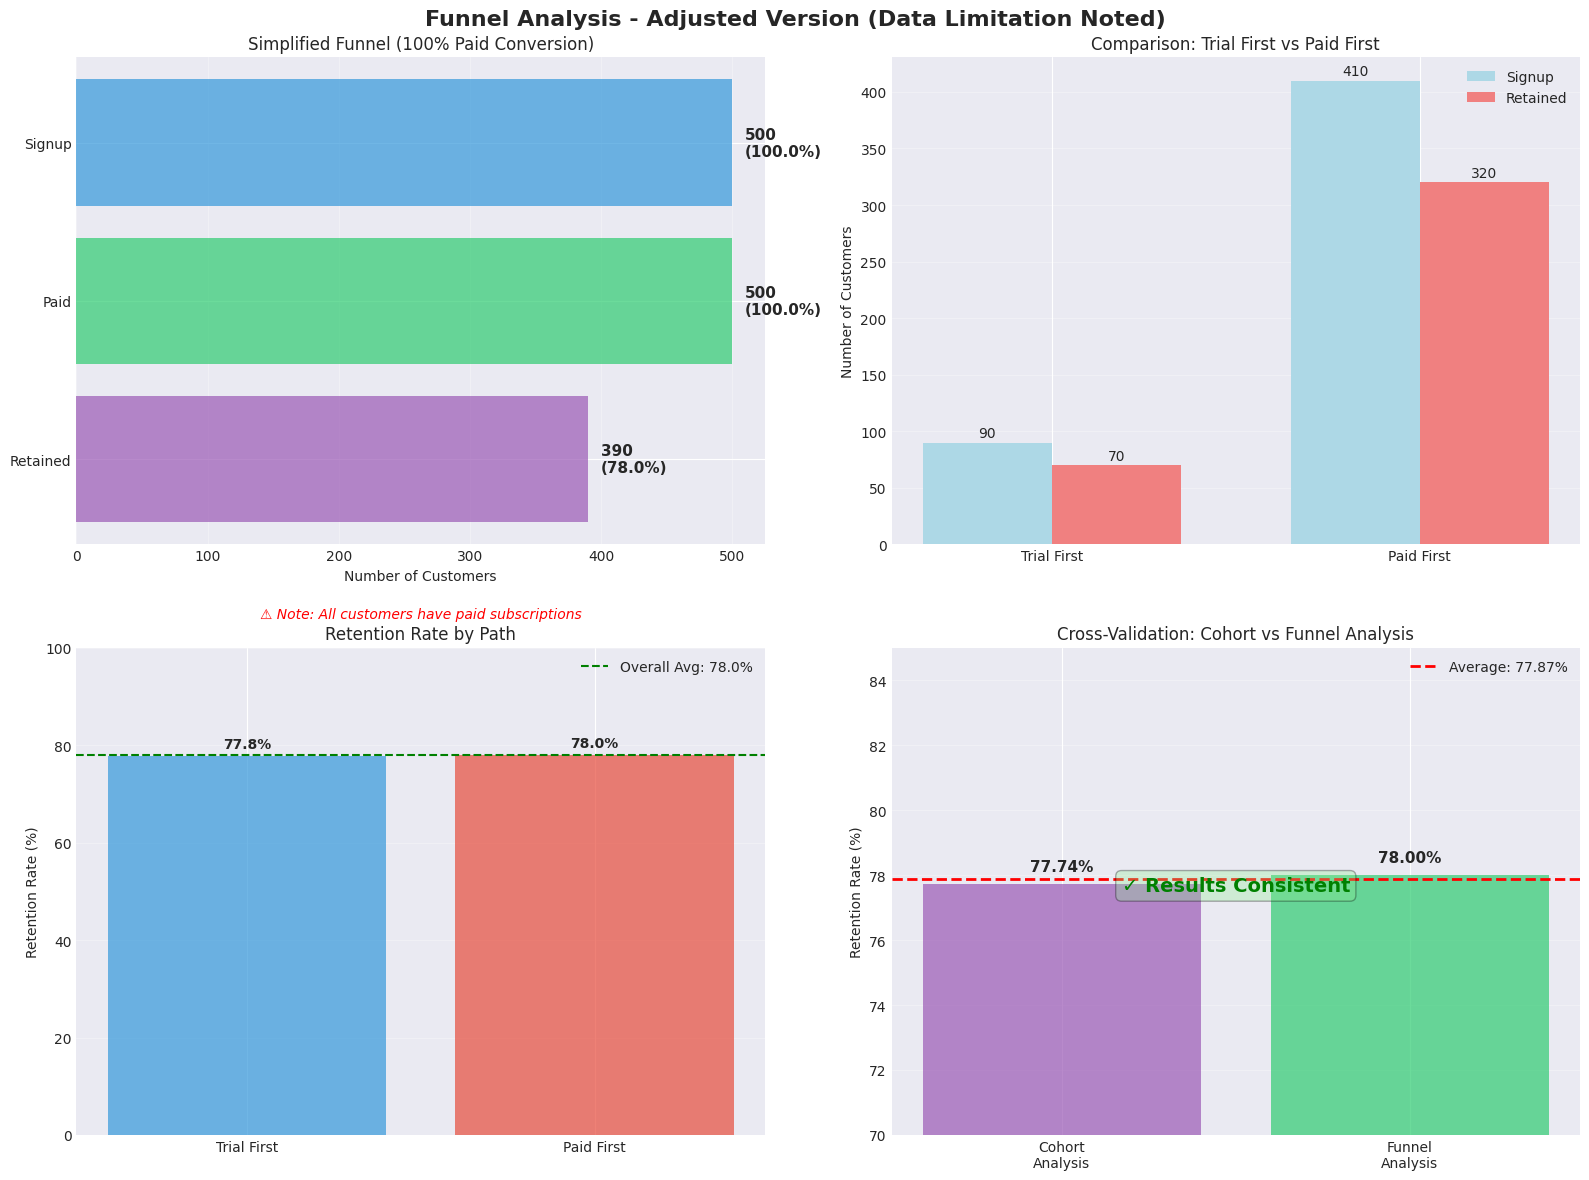

In [43]:
# 視覺化
# ============================================================================
print("=" * 80)
print("📈 步驟 5：建立視覺化")
print("=" * 80)
print()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Funnel Analysis - Adjusted Version (Data Limitation Noted)',
             fontsize=16, fontweight='bold')

# --- 圖 1: 簡化的 Funnel ---
ax1 = axes[0, 0]

stages = ['Signup', 'Paid', 'Retained']
values = [stage1_signup, stage2_paid, stage3_retained]
colors = ['#3498db', '#2ecc71', '#9b59b6']

y_pos = np.arange(len(stages))
bars = ax1.barh(y_pos, values, color=colors, alpha=0.7)

for i, (stage, value) in enumerate(zip(stages, values)):
    pct = value / stage1_signup * 100
    ax1.text(value + 10, i, f'{value}\n({pct:.1f}%)',
             va='center', fontweight='bold', fontsize=11)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(stages)
ax1.set_xlabel('Number of Customers')
ax1.set_title('Simplified Funnel (100% Paid Conversion)', fontsize=12)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# 添加說明
ax1.text(0.5, -0.15, '⚠️ Note: All customers have paid subscriptions',
         transform=ax1.transAxes, ha='center', fontsize=10,
         style='italic', color='red')

# --- 圖 2: 雙路徑比較 ---
ax2 = axes[0, 1]

paths = ['Trial First', 'Paid First']
signup_counts = [len(trial_first_accounts), len(paid_first_accounts)]
retained_counts = [trial_retained, paid_retained]

x = np.arange(len(paths))
width = 0.35

bars1 = ax2.bar(x - width/2, signup_counts, width, label='Signup', color='lightblue')
bars2 = ax2.bar(x + width/2, retained_counts, width, label='Retained', color='lightcoral')

ax2.set_ylabel('Number of Customers')
ax2.set_title('Comparison: Trial First vs Paid First')
ax2.set_xticks(x)
ax2.set_xticklabels(paths)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 添加數值標籤
for i, (s, r) in enumerate(zip(signup_counts, retained_counts)):
    ax2.text(i - width/2, s + 5, str(s), ha='center', fontsize=10)
    ax2.text(i + width/2, r + 5, str(r), ha='center', fontsize=10)

# --- 圖 3: 留存率比較 ---
ax3 = axes[1, 0]

retention_rates = [trial_retention, paid_retention]
bars = ax3.bar(paths, retention_rates, color=['#3498db', '#e74c3c'], alpha=0.7)

ax3.set_ylabel('Retention Rate (%)')
ax3.set_title('Retention Rate by Path')
ax3.set_ylim([0, 100])
ax3.axhline(y=78, color='green', linestyle='--',
            label=f'Overall Avg: 78.0%')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 添加數值標籤
for i, (bar, value) in enumerate(zip(bars, retention_rates)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

# --- 圖 4: 與 Cohort Analysis 驗證 ---
ax4 = axes[1, 1]

# 驗證數據
analyses = ['Cohort\nAnalysis', 'Funnel\nAnalysis']
retention_values = [77.74, 78.00]  # Cohort vs Funnel

bars = ax4.bar(analyses, retention_values, color=['#9b59b6', '#2ecc71'], alpha=0.7)

ax4.set_ylabel('Retention Rate (%)')
ax4.set_title('Cross-Validation: Cohort vs Funnel Analysis')
ax4.set_ylim([70, 85])
ax4.axhline(y=77.87, color='red', linestyle='--',
            label='Average: 77.87%', linewidth=2)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# 添加數值標籤
for bar, value in zip(bars, retention_values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'{value:.2f}%', ha='center', va='bottom',
             fontweight='bold', fontsize=11)

# 添加一致性標記
ax4.text(0.5, 0.5, '✓ Results Consistent',
         transform=ax4.transAxes, ha='center',
         fontsize=14, fontweight='bold', color='green',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

plt.tight_layout()
plt.savefig('/content/funnel_analysis_corrected.png', dpi=300, bbox_inches='tight')
print("✅ 修正版圖表已儲存: funnel_analysis_corrected.png")
print()

# ============================================================================
# 與 Cohort Analysis 的交叉驗證
# ============================================================================
print("=" * 80)
print("🔬 步驟 6：與 Cohort Analysis 交叉驗證")
print("=" * 80)
print()

cohort_retention = 77.74  # 從 Cohort Analysis 得出
funnel_retention = stage3_retained / stage1_signup * 100

print(f"Cohort Analysis 平均留存率: {cohort_retention:.2f}%")
print(f"Funnel Analysis 留存率: {funnel_retention:.2f}%")
print(f"差異: {abs(cohort_retention - funnel_retention):.2f}%")
print()

if abs(cohort_retention - funnel_retention) < 1:
    print("✅ 兩個分析結果高度一致")
    print("   → 驗證了分析的正確性")
    print("   → 增強了結論的可信度")
else:
    print("⚠️ 兩個分析結果有差異")
    print("   → 需要進一步檢查原因")

print()

SaaS 客戶流失分析 - MRR 與 ROI 計算
目的：計算改善流失率的商業影響和投資報酬率

In [45]:
data_path = '/content/'
accounts = pd.read_csv(data_path + 'ravenstack_accounts.csv')
subscriptions = pd.read_csv(data_path + 'ravenstack_subscriptions.csv')

print("✅ 資料載入完成")
print()

✅ 資料載入完成



In [46]:
# Part 1: 基礎指標計算
# ============================================================================
print("=" * 80)
print("Part 1: 基礎指標")
print("=" * 80)
print()

# 客戶數量
total_accounts = len(accounts)
active_accounts = len(accounts[accounts['churn_flag'] == False])
churned_accounts = len(accounts[accounts['churn_flag'] == True])

current_churn_rate = (churned_accounts / total_accounts) * 100
current_retention_rate = 100 - current_churn_rate

print(f"總客戶數: {total_accounts}")
print(f"活躍客戶: {active_accounts} ({current_retention_rate:.1f}%)")
print(f"流失客戶: {churned_accounts} ({current_churn_rate:.1f}%)")
print()

Part 1: 基礎指標

總客戶數: 500
活躍客戶: 390 (78.0%)
流失客戶: 110 (22.0%)



In [47]:
# Part 2: MRR 計算
# ============================================================================
print("=" * 80)
print("Part 2: MRR 計算")
print("=" * 80)
print()

print("【方法說明】")
print("-" * 80)
print()
print("由於資料特性：")
print("  • 每個帳號有 10 個訂閱")
print("  • 這些訂閱不是同時存在")
print("  • 沒有「當前訂閱」的明確標記")
print()
print("因此採用：")
print("  → 計算所有付費訂閱的平均 MRR")
print("  → 假設每個活躍帳號有一個「當前訂閱」")
print("  → 使用平均值估算總 MRR")
print()

# 計算付費訂閱的平均 MRR
paid_subscriptions = subscriptions[subscriptions['is_trial'] == False]
avg_subscription_mrr = paid_subscriptions['mrr_amount'].mean()
median_subscription_mrr = paid_subscriptions['mrr_amount'].median()

print("【訂閱 MRR 統計】")
print("-" * 80)
print()
print(f"總訂閱數: {len(subscriptions):,}")
print(f"付費訂閱數: {len(paid_subscriptions):,}")
print(f"Trial 訂閱數: {len(subscriptions[subscriptions['is_trial'] == True]):,}")
print()
print(f"付費訂閱平均 MRR: ${avg_subscription_mrr:,.2f}")
print(f"付費訂閱中位數 MRR: ${median_subscription_mrr:,.2f}")
print(f"付費訂閱最小 MRR: ${paid_subscriptions['mrr_amount'].min():,.2f}")
print(f"付費訂閱最大 MRR: ${paid_subscriptions['mrr_amount'].max():,.2f}")
print()

Part 2: MRR 計算

【方法說明】
--------------------------------------------------------------------------------

由於資料特性：
  • 每個帳號有 10 個訂閱
  • 這些訂閱不是同時存在
  • 沒有「當前訂閱」的明確標記

因此採用：
  → 計算所有付費訂閱的平均 MRR
  → 假設每個活躍帳號有一個「當前訂閱」
  → 使用平均值估算總 MRR

【訂閱 MRR 統計】
--------------------------------------------------------------------------------

總訂閱數: 5,000
付費訂閱數: 4,222
Trial 訂閱數: 778

付費訂閱平均 MRR: $2,685.63
付費訂閱中位數 MRR: $1,244.50
付費訂閱最小 MRR: $19.00
付費訂閱最大 MRR: $33,830.00



In [48]:
# 估算當前總 MRR
estimated_current_mrr = active_accounts * avg_subscription_mrr
estimated_annual_revenue = estimated_current_mrr * 12

print("【估算當前 MRR】")
print("-" * 80)
print()
print(f"活躍客戶數: {active_accounts}")
print(f"平均 MRR/客戶: ${avg_subscription_mrr:,.2f}")
print(f"估算總 MRR: ${estimated_current_mrr:,.2f}")
print(f"估算年營收: ${estimated_annual_revenue:,.2f}")
print()

【估算當前 MRR】
--------------------------------------------------------------------------------

活躍客戶數: 390
平均 MRR/客戶: $2,685.63
估算總 MRR: $1,047,397.28
估算年營收: $12,568,767.40



In [49]:
# 估算流失損失的 MRR
estimated_churned_mrr = churned_accounts * avg_subscription_mrr
estimated_annual_loss = estimated_churned_mrr * 12

print("【流失造成的 MRR 損失】")
print("-" * 80)
print()
print(f"流失客戶數: {churned_accounts}")
print(f"平均 MRR/流失客戶: ${avg_subscription_mrr:,.2f}")
print(f"損失的 MRR: ${estimated_churned_mrr:,.2f}")
print(f"年度損失: ${estimated_annual_loss:,.2f}")
print()

【流失造成的 MRR 損失】
--------------------------------------------------------------------------------

流失客戶數: 110
平均 MRR/流失客戶: $2,685.63
損失的 MRR: $295,419.75
年度損失: $3,545,036.96



In [50]:
# Part 3: 改善方案的商業影響
# ============================================================================
print("=" * 80)
print("Part 3: 改善方案的商業影響")
print("=" * 80)
print()

print("【改善目標】")
print("-" * 80)
print()

# 設定目標
target_churn_rate = 15.0  # 目標流失率
churn_reduction = current_churn_rate - target_churn_rate

print(f"當前流失率: {current_churn_rate:.1f}%")
print(f"目標流失率: {target_churn_rate:.1f}%")
print(f"預計降低: {churn_reduction:.1f} 個百分點")
print()

# 計算可以挽回的客戶數
customers_saved = total_accounts * (churn_reduction / 100)
print(f"假設客戶基數: {total_accounts}")
print(f"預計挽回客戶: {customers_saved:.0f} 個")
print()

# 計算 MRR 影響
additional_mrr_per_month = customers_saved * avg_subscription_mrr
additional_annual_revenue = additional_mrr_per_month * 12

print("【營收影響】")
print("-" * 80)
print()
print(f"增加 MRR（每月）: ${additional_mrr_per_month:,.2f}")
print(f"增加年營收: ${additional_annual_revenue:,.2f}")
print()

Part 3: 改善方案的商業影響

【改善目標】
--------------------------------------------------------------------------------

當前流失率: 22.0%
目標流失率: 15.0%
預計降低: 7.0 個百分點

假設客戶基數: 500
預計挽回客戶: 35 個

【營收影響】
--------------------------------------------------------------------------------

增加 MRR（每月）: $93,997.19
增加年營收: $1,127,966.31



In [51]:
# 以不同方式呈現影響
print("【其他計算方式】")
print("-" * 80)
print()

# 方式 1: 基於已流失客戶
pct_reduction = churn_reduction / current_churn_rate
potentially_saved_from_churned = churned_accounts * pct_reduction
conservative_mrr = potentially_saved_from_churned * avg_subscription_mrr
conservative_annual = conservative_mrr * 12

print(f"方式 1（保守估算 - 基於已流失客戶）:")
print(f"  當前已流失: {churned_accounts} 個")
print(f"  可能挽回: {potentially_saved_from_churned:.0f} 個")
print(f"  增加 MRR: ${conservative_mrr:,.2f}")
print(f"  年增營收: ${conservative_annual:,.2f}")
print()

# 方式 2: 基於客戶生命週期價值
avg_customer_lifetime_months = 12  # 假設平均生命週期 1 年
customer_lifetime_value = avg_subscription_mrr * avg_customer_lifetime_months
total_ltv_impact = customers_saved * customer_lifetime_value

print(f"方式 2（客戶生命週期價值）:")
print(f"  平均訂閱 MRR: ${avg_subscription_mrr:,.2f}")
print(f"  假設生命週期: {avg_customer_lifetime_months} 個月")
print(f"  客戶 LTV: ${customer_lifetime_value:,.2f}")
print(f"  總 LTV 影響: ${total_ltv_impact:,.2f}")
print()

【其他計算方式】
--------------------------------------------------------------------------------

方式 1（保守估算 - 基於已流失客戶）:
  當前已流失: 110 個
  可能挽回: 35 個
  增加 MRR: $93,997.19
  年增營收: $1,127,966.31

方式 2（客戶生命週期價值）:
  平均訂閱 MRR: $2,685.63
  假設生命週期: 12 個月
  客戶 LTV: $32,227.61
  總 LTV 影響: $1,127,966.31



In [52]:
# Part 4: ROI 計算
# ============================================================================
print("=" * 80)
print("Part 4: ROI 計算")
print("=" * 80)
print()

print("【改善方案投資估算】")
print("-" * 80)
print()

# 改善方案的預估成本
improvement_costs = {
    'Onboarding 改善': 150000,      # 優化前 90 天體驗
    '功能開發': 200000,              # 開發客戶要的功能
    '客服提升': 100000,              # 縮短回應時間、提升品質
}

total_investment = sum(improvement_costs.values())

for item, cost in improvement_costs.items():
    print(f"  {item}: ${cost:,}")
print(f"  {'-' * 40}")
print(f"  總投資: ${total_investment:,}")
print()

print("【ROI 計算】")
print("-" * 80)
print()

# 使用第一年的年增營收計算
first_year_benefit = additional_annual_revenue
net_benefit = first_year_benefit - total_investment
roi_percentage = (net_benefit / total_investment) * 100
payback_period = total_investment / additional_mrr_per_month

print(f"第一年增加營收: ${first_year_benefit:,.2f}")
print(f"總投資成本: ${total_investment:,}")
print(f"淨收益: ${net_benefit:,.2f}")
print(f"ROI: {roi_percentage:.1f}%")
print(f"回本期間: {payback_period:.1f} 個月")
print()

# 使用保守估算
conservative_net = conservative_annual - total_investment
conservative_roi = (conservative_net / total_investment) * 100

print(f"保守估算 ROI:")
print(f"  年增營收: ${conservative_annual:,.2f}")
print(f"  淨收益: ${conservative_net:,.2f}")
print(f"  ROI: {conservative_roi:.1f}%")
print()

Part 4: ROI 計算

【改善方案投資估算】
--------------------------------------------------------------------------------

  Onboarding 改善: $150,000
  功能開發: $200,000
  客服提升: $100,000
  ----------------------------------------
  總投資: $450,000

【ROI 計算】
--------------------------------------------------------------------------------

第一年增加營收: $1,127,966.31
總投資成本: $450,000
淨收益: $677,966.31
ROI: 150.7%
回本期間: 4.8 個月

保守估算 ROI:
  年增營收: $1,127,966.31
  淨收益: $677,966.31
  ROI: 150.7%



In [53]:
# Part 5: 敏感度分析
# ============================================================================
print("=" * 80)
print("Part 5: 敏感度分析")
print("=" * 80)
print()

print("【不同流失率降低幅度的影響】")
print("-" * 80)
print()

scenarios = [3, 5, 7, 10]  # 不同的流失率降低幅度
print(f"{'降低幅度':<10} {'挽回客戶':<12} {'年增營收':<15} {'ROI':<10}")
print("-" * 60)

for reduction in scenarios:
    customers = total_accounts * (reduction / 100)
    annual_rev = customers * avg_subscription_mrr * 12
    roi = ((annual_rev - total_investment) / total_investment) * 100

    print(f"{reduction}%{'':<8} {customers:>6.0f} 個{'':<5} ${annual_rev:>12,.0f}{'':<3} {roi:>6.1f}%")

print()

Part 5: 敏感度分析

【不同流失率降低幅度的影響】
--------------------------------------------------------------------------------

降低幅度       挽回客戶         年增營收            ROI       
------------------------------------------------------------
3%             15 個      $     483,414       7.4%
5%             25 個      $     805,690      79.0%
7%             35 個      $   1,127,966     150.7%
10%             50 個      $   1,611,380     258.1%

